# ROI Crossnobis RSA — group results

Crossnobis RDMs over the 8 stimulus identities from GLMsingle type-D cue betas, produced by
`run_rsa_roi.py`. Masks: whole brain, visual cortex, fusiform, vmPFC, striatum,
habit (Guida 2022), putamen (AAL), premotor (HMAT), parietal (AAL).

The question: *are stimuli with similar objective value represented more similarly?* Unlike
the high/low classifier, this makes a prediction identity and category cannot mimic — the
three pairs of stimuli that **share** a reward level should be extra-similar despite being
different images in different categories.

Prerequisites, both already run:
[`rsa_design_checks.ipynb`](rsa_design_checks.ipynb) (what the design allows) ·
[`crossnobis_validation.ipynb`](crossnobis_validation.ipynb) (that the distance is correct)

## Reading the numbers

Established in [`rsa_design_checks.ipynb`](rsa_design_checks.ipynb) (n=62):

- **`subset='nonfigure'` is primary.** Values {1,5} always sit on `figure` (62/62), so the
  all-8 version cannot separate extreme value from figure-vs-rest.
- **The "frequency" regressor is *choice* frequency, not presentation frequency.** Every
  stimulus is shown equally often (§1b: first-stim counts identical at 84 per stimulus for
  the ±1 label, zero variance); the label encodes how often the subject *chose* the
  stimulus, manipulated via pairing with higher-/lower-valued alternatives. `model='ck'`
  swaps the categorical label for the graded choice-kernel H-value (`|ΔH|`) in the same
  regressor slot — see §8a.
- **Value stays in the model** — corr(value, choice-frequency) = −0.346, fixed for everyone.
- **The same-value contrast is conservative**: those pairs carry the maximal |Δfreq|.

Conventions:

- Model RDMs are *dis*similarity predictions → **positive β = represented**.
- `contrast_value` = mean(diff-value) − mean(same-value) → **positive = value coding**.
- β are standardised partial weights (RDM and predictors z-scored), comparable across
  subjects and ROIs. Tested against 0, which crossnobis's unbiasedness licenses.
- No identity regressor: every off-diagonal cell is different-identity, so identity *is*
  the intercept.

**Status:** run 2026-08-27, n=58 (`participants_mvpa.tsv` minus `sub-46`); rerun same day
with the `ck` model variant. See Findings at the bottom.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from statsmodels.stats.multitest import multipletests

DERIV_DIR = Path("/Users/hugofluhr/phd_local/data/LearningHabits/dev_sample/bids_dataset/derivatives")
RSA_DIR = DERIV_DIR / "rsa"
RSA_SHUFFLED_DIR = DERIV_DIR / "rsa_shuffled"   # negative control; may be absent

MASKS = ["wholebrain", "visualcortex", "fusiform", "vmpfc", "striatum",
         "habit", "putamen", "premotor", "parietal"]
MASK_LABELS = {"wholebrain": "Whole brain", "visualcortex": "Visual cortex",
               "fusiform": "Fusiform", "vmpfc": "vmPFC", "striatum": "Striatum",
               "habit": "Habit (Guida)", "putamen": "Putamen", "premotor": "Premotor",
               "parietal": "Parietal"}
COLORS = {"wholebrain": "#4C72B0", "visualcortex": "#DD8452", "fusiform": "#937860",
          "vmpfc": "#55A868", "striatum": "#C44E52",
          "habit": "#8172B3", "putamen": "#CCB974", "premotor": "#64B5CD",
          "parietal": "#8C8C8C"}

SCOPES = ["pooled", "learning1", "learning2", "test"]
RUN_SCOPES = ["learning1", "learning2", "test"]

# The 3 terms of interest + 2 confound-control regressors.
# second_stim_value: |Δ(mean value of the paired alternative)| per first-stim identity.
# choice_rate: |Δ(P(chose first stim))| — captures decision/motor confounds.
MODEL_TERMS = ["category", "value", "frequency", "second_stim_value", "choice_rate"]
TERMS_OF_INTEREST = ["category", "value", "frequency"]   # plotted in main bar charts
TERM_COLORS = {"category": "#8172B3", "value": "#C44E52", "frequency": "#64B5CD",
               "second_stim_value": "#CCB974", "choice_rate": "#8C8C8C"}

# Primary readouts. 'nonfigure' is the counterbalanced test (values {1,5} always sit on
# the figure category, so the all-8 version cannot separate extreme value from
# figure-vs-rest); 'objective' is the fixed reward level, 'rl' the model-derived Q.
# 'frequency' throughout is CHOICE frequency (equal presentations; manipulated via
# pairing) -- 'ck' swaps the categorical +-1 label for the graded choice-kernel |dH|
# in that same regressor slot (see SS8a).
PRIMARY_SUBSET = "nonfigure"
PRIMARY_MODEL = "objective"

In [2]:
def load_results(rsa_dir):
    """Concatenate every subject's long-format RSA results CSV."""
    files = sorted(Path(rsa_dir).glob("sub-*/sub-*_rsa_results.csv"))
    if not files:
        return pd.DataFrame()
    return pd.concat([pd.read_csv(f) for f in files], ignore_index=True)


def load_rdms(rsa_dir, mask, scope):
    """{subject: 8x8 crossnobis RDM} for one mask/scope, rows ordered as stim_names."""
    out = {}
    for f in sorted(Path(rsa_dir).glob(f"sub-*/sub-*_rsa_rdm_{mask}_{scope}.npy")):
        out[f.parent.name] = np.load(f)
    return out


def load_model_rdms(rsa_dir):
    """{subject: npz} of per-subject model RDMs and per-stimulus properties."""
    out = {}
    for f in sorted(Path(rsa_dir).glob("sub-*/sub-*_rsa_model_rdms.npz")):
        out[f.parent.name] = np.load(f, allow_pickle=True)
    return out


def group_test(values):
    """One-sample t-test and Wilcoxon against 0, plus mean/sem. Valid against 0 because
    crossnobis distances are unbiased under the null, so the regression coefficients are
    too (no need for a permutation reference for the location test)."""
    v = np.asarray(values, dtype=float)
    v = v[np.isfinite(v)]
    if len(v) < 3:
        return dict(n=len(v), mean=np.nan, sem=np.nan, t=np.nan, p=np.nan, p_wilcoxon=np.nan)
    t, p = stats.ttest_1samp(v, 0)
    try:
        _, pw = stats.wilcoxon(v)
    except ValueError:
        pw = np.nan
    return dict(n=len(v), mean=v.mean(), sem=v.std(ddof=1) / np.sqrt(len(v)),
                t=float(t), p=float(p), p_wilcoxon=float(pw))


def summarise(df, column, scope="pooled", subset=PRIMARY_SUBSET, model=PRIMARY_MODEL):
    """Group test of `column` per mask, for one (scope, subset, model) slice."""
    sel = df[(df.scope == scope) & (df["subset"] == subset) & (df.model == model)]
    rows = []
    for mask in MASKS:
        vals = sel.loc[sel["mask"] == mask, column].values
        rows.append(dict(mask=mask, **group_test(vals)))
    return pd.DataFrame(rows).set_index("mask")


def stars(p):
    if not np.isfinite(p):
        return ""
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""


df = load_results(RSA_DIR)
df_shuf = load_results(RSA_SHUFFLED_DIR)
model_rdms = load_model_rdms(RSA_DIR)

print(f"real:     {df.subject.nunique() if len(df) else 0} subjects, {len(df)} rows")
print(f"shuffled: {df_shuf.subject.nunique() if len(df_shuf) else 0} subjects")
if len(df):
    print("scopes:", sorted(df.scope.unique()), "| subsets:", sorted(df['subset'].unique()),
          "| models:", sorted(df.model.unique()))
    print("within-run split:", df.within_run_split.unique())
    print("\nvoxels per mask (median):")
    print(df.groupby("mask").n_voxels.median().reindex(MASKS).to_string())

real:     58 subjects, 12528 rows
shuffled: 58 subjects
scopes: ['learning1', 'learning2', 'pooled', 'test'] | subsets: ['all', 'nonfigure'] | models: ['ck', 'objective', 'rl']
within-run split: ['interleaved']

voxels per mask (median):
mask
wholebrain      64620.0
visualcortex     7600.0
fusiform          320.0
vmpfc             119.0
striatum          128.0
habit             657.0
putamen           500.0
premotor         4334.0
parietal         2866.0


## 1. Model RDMs

Re-derived from the saved npz files, i.e. from the data actually processed. Should match
`rsa_design_checks.ipynb`.

In [3]:
# Re-derive the design facts from the processed data rather than trusting the docstring.
iu = np.triu_indices(8, 1)
rows, assignments = [], set()
for sub, npz in model_rdms.items():
    cat, val, frq = npz["category"], npz["value"], npz["frequency"]
    c, v, f = cat[iu], val[iu], frq[iu]
    nf = npz["non_figure"]
    names, values = npz["stim_names"], npz["stim_value"]
    assignments.add(tuple(zip(map(str, names), values.astype(int))))
    same_v, cross = v == 0, c > 0
    rows.append(dict(
        subject=sub,
        r_cat_val=np.corrcoef(c, v)[0, 1], r_cat_frq=np.corrcoef(c, f)[0, 1],
        r_val_frq=np.corrcoef(v, f)[0, 1],
        n_nonfigure=int(nf.sum()), n_same_value=int(same_v.sum()),
        same_value_all_cross=bool(cross[same_v].all()),
        dfrq_same_value=f[same_v].mean(), dfrq_diff_value=f[~same_v & cross].mean(),
        extreme_cat="/".join(sorted(set(np.asarray(npz["stim_cat"])[np.isin(values, [1, 5])]))),
    ))
mr = pd.DataFrame(rows)

print(f"distinct image->value assignments across {len(mr)} subjects: {len(assignments)}")
print(f"category holding values {{1,5}}: {mr.extreme_cat.value_counts().to_dict()}")
print(f"all same-value pairs cross-category: {mr.same_value_all_cross.all()}")
print(f"\nmodel RDM intercorrelations (min .. max across subjects):")
for c in ["r_cat_val", "r_cat_frq", "r_val_frq"]:
    print(f"  {c:11s} {mr[c].min():+.3f} .. {mr[c].max():+.3f}")
print(f"\nmean |dfreq| on same-value pairs   : {mr.dfrq_same_value.mean():.3f}")
print(f"mean |dfreq| on diff-value x-cat   : {mr.dfrq_diff_value.mean():.3f}"
      "   <- frequency runs AGAINST the value hypothesis in contrast_value")

distinct image->value assignments across 58 subjects: 12
category holding values {1,5}: {'figure': 58}
all same-value pairs cross-category: True

model RDM intercorrelations (min .. max across subjects):
  r_cat_val   -0.179 .. -0.179
  r_cat_frq   -0.232 .. +0.310
  r_val_frq   -0.346 .. -0.346

mean |dfreq| on same-value pairs   : 2.000
mean |dfreq| on diff-value x-cat   : 0.995   <- frequency runs AGAINST the value hypothesis in contrast_value


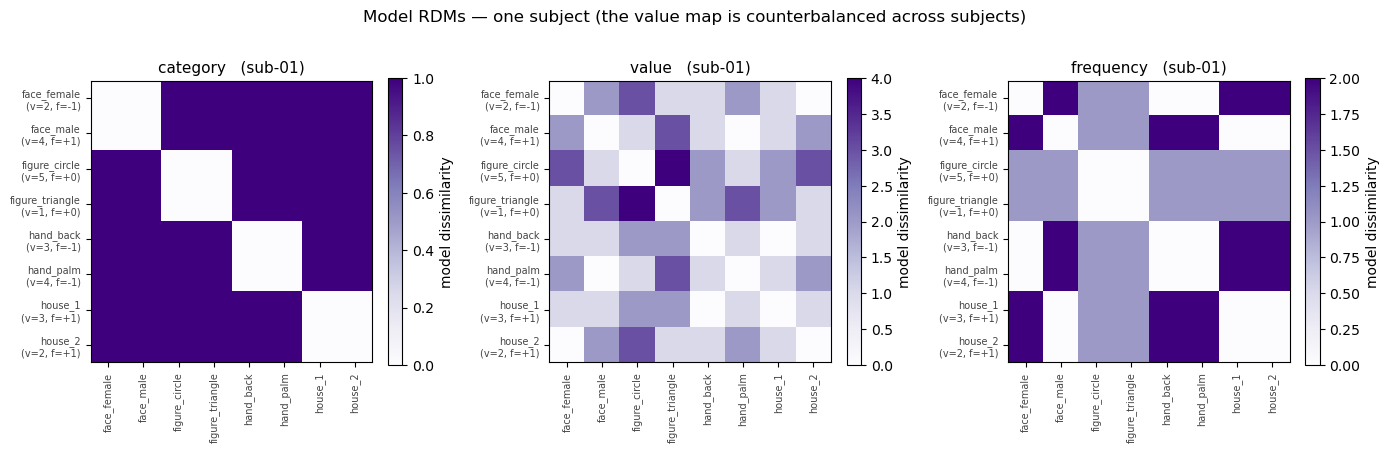

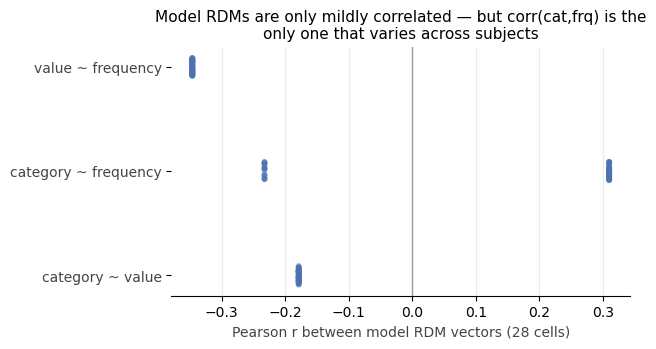

In [4]:
# One example subject's model RDMs. Non-negative dissimilarity predictions -> sequential
# single-hue map (see the signed crossnobis RDMs below for why those differ).
ex_sub = sorted(model_rdms)[0]
npz = model_rdms[ex_sub]
labels = [f"{n}\n(v={int(v)}, f={int(f):+d})" for n, v, f
          in zip(npz["stim_names"], npz["stim_value"], npz["stim_frequency"])]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.6))
for ax, term in zip(axes, MODEL_TERMS):
    m = npz[term]
    im = ax.imshow(m, cmap="Purples", vmin=0)
    ax.set_title(f"{term}   ({ex_sub})", fontsize=11)
    ax.set_xticks(range(8)); ax.set_yticks(range(8))
    ax.set_xticklabels(npz["stim_names"], rotation=90, fontsize=7, color="#444444")
    ax.set_yticklabels(labels, fontsize=7, color="#444444")
    fig.colorbar(im, ax=ax, fraction=0.046, label="model dissimilarity")
fig.suptitle("Model RDMs — one subject (the value map is counterbalanced across subjects)",
             fontsize=12)
fig.tight_layout()
plt.show()

# Intercorrelation spread across subjects. corr(cat,val) and corr(val,frq) are fixed by
# the design; corr(cat,frq) is the only one that varies, which is what lets the
# regression separate the category and frequency terms at the group level.
fig, ax = plt.subplots(figsize=(6.5, 3.6))
pairs = [("r_cat_val", "category ~ value"), ("r_cat_frq", "category ~ frequency"),
         ("r_val_frq", "value ~ frequency")]
for i, (col, lab) in enumerate(pairs):
    ax.scatter(mr[col], np.full(len(mr), i) + np.random.uniform(-.09, .09, len(mr)),
               s=18, color="#4C72B0", alpha=.55, edgecolor="none", zorder=3)
ax.axvline(0, color="#999999", linewidth=1, zorder=1)
ax.set_yticks(range(len(pairs))); ax.set_yticklabels([p[1] for p in pairs], color="#444444")
ax.set_xlabel("Pearson r between model RDM vectors (28 cells)", color="#444444")
ax.set_title("Model RDMs are only mildly correlated — but corr(cat,frq) is the\n"
             "only one that varies across subjects", fontsize=11)
ax.grid(axis="x", alpha=.25, zorder=0); ax.set_axisbelow(True)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
fig.tight_layout()
plt.show()

### 1b. Model matrix condition number and VIF

With 5 regressors (category, value, frequency, second_stim_value, choice_rate) fit on
only 15 upper-triangle cells (non-figure subset), multicollinearity could destabilise
partial coefficients. Compute the condition number (κ) and variance inflation factors
per subject on the actual z-scored model matrix.

In [5]:
# §1b — Condition number and VIF of the 5-predictor model matrix
# The regression fits 15 upper-triangle cells (6 non-figure stimuli) on 5 z-scored
# model RDMs + intercept.  Category and frequency RDMs are fixed across subjects;
# value, second_stim_value, and choice_rate vary (objective model shown here; rl/ck
# swap only one term and produce similar collinearity).

def _z(v):
    v = np.asarray(v, dtype=float)
    s = v.std()
    return (v - v.mean()) / s if s > 0 else v - v.mean()

def _triu(m):
    return m[np.triu_indices(m.shape[0], k=1)]

def vif_from_X(X):
    """VIF for each column of a design matrix (no intercept column expected)."""
    from numpy.linalg import lstsq
    p = X.shape[1]
    vifs = np.empty(p)
    for j in range(p):
        y_j = X[:, j]
        X_rest = np.delete(X, j, axis=1)
        X_aug = np.column_stack([np.ones(len(y_j)), X_rest])
        coef, *_ = lstsq(X_aug, y_j, rcond=None)
        y_hat = X_aug @ coef
        ss_res = ((y_j - y_hat) ** 2).sum()
        ss_tot = ((y_j - y_j.mean()) ** 2).sum()
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0
        vifs[j] = 1 / (1 - r2) if r2 < 1 else np.inf
    return vifs

scope = "pooled"
non_fig = None
rows_vif = []
for sub_id, npz in model_rdms.items():
    if non_fig is None:
        non_fig = npz["non_figure"]
    keep = non_fig
    cat_rdm = npz["category"]
    val_rdm = npz["value"]           # objective value (fixed by design)
    freq_rdm = npz["frequency"]
    s2v_rdm = npz[f"s2v_{scope}"]
    cr_rdm = npz[f"cr_{scope}"]

    sub_idx = np.ix_(keep, keep)
    cols = []
    for rdm in [cat_rdm, val_rdm, freq_rdm, s2v_rdm, cr_rdm]:
        v = _triu(rdm[sub_idx])
        cols.append(_z(v))
    X = np.column_stack(cols)

    kappa = np.linalg.cond(X)
    vifs = vif_from_X(X)
    rows_vif.append({"subject": sub_id, "cond_number": kappa,
                     **{f"VIF_{t}": v for t, v in zip(MODEL_TERMS, vifs)}})

vif_df = pd.DataFrame(rows_vif).set_index("subject").sort_index()

print(f"Model matrix diagnostics (scope={scope}, subset=nonfigure, model=objective)")
print(f"  n_subjects = {len(vif_df)}")
print(f"  n_pairs (upper-tri cells) = {len(_triu(cat_rdm[sub_idx]))}")
print(f"  n_predictors = {len(MODEL_TERMS)}")
print()
print("Condition number κ(X):")
print(f"  median = {vif_df.cond_number.median():.1f}")
print(f"  max    = {vif_df.cond_number.max():.1f}")
print(f"  subjects with κ > 30: {(vif_df.cond_number > 30).sum()}")
print()
vif_cols = [c for c in vif_df.columns if c.startswith("VIF_")]
print("VIF per predictor (median [min–max] across subjects):")
for c in vif_cols:
    term = c.replace("VIF_", "")
    lo, med, hi = vif_df[c].min(), vif_df[c].median(), vif_df[c].max()
    flag = " ⚠️" if med > 5 else ""
    print(f"  {term:20s}  {med:.2f}  [{lo:.2f} – {hi:.2f}]{flag}")
print()
print("Rule of thumb: κ < 30 and VIF < 5–10 are acceptable.")

Model matrix diagnostics (scope=pooled, subset=nonfigure, model=objective)
  n_subjects = 58
  n_pairs (upper-tri cells) = 15
  n_predictors = 5

Condition number κ(X):
  median = 2.7
  max    = 4.1
  subjects with κ > 30: 0

VIF per predictor (median [min–max] across subjects):
  category              1.24  [1.11 – 1.97]
  value                 1.92  [1.34 – 4.35]
  frequency             1.24  [1.17 – 1.84]
  second_stim_value     1.98  [1.29 – 3.57]
  choice_rate           1.46  [1.10 – 2.39]

Rule of thumb: κ < 30 and VIF < 5–10 are acceptable.


## 2. Group RDMs

Two views, because subjects have different image → value mappings:

- **image space** — structure here is visual (category/identity); value is scrambled by the
  counterbalancing. Sanity check: category blocks should show in visual cortex.
- **value space** — each subject's RDM reordered by *their* stimulus values before
  averaging. Value structure survives this; idiosyncratic image similarity doesn't.

Crossnobis is signed, so the maps are diverging with a neutral midpoint at 0.

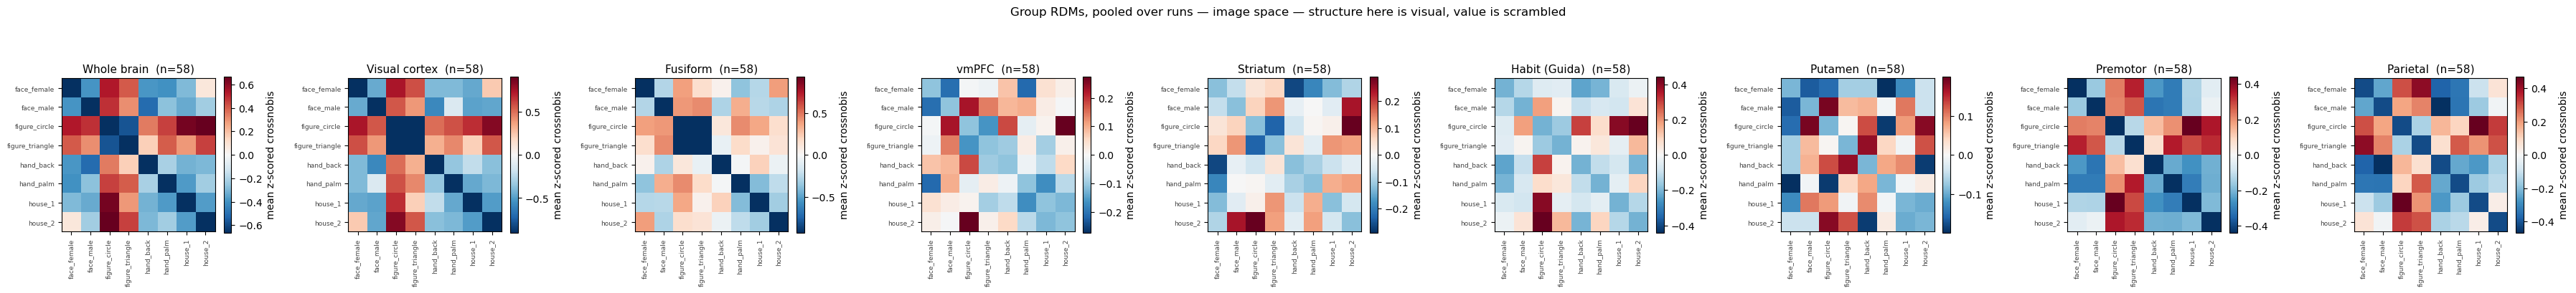

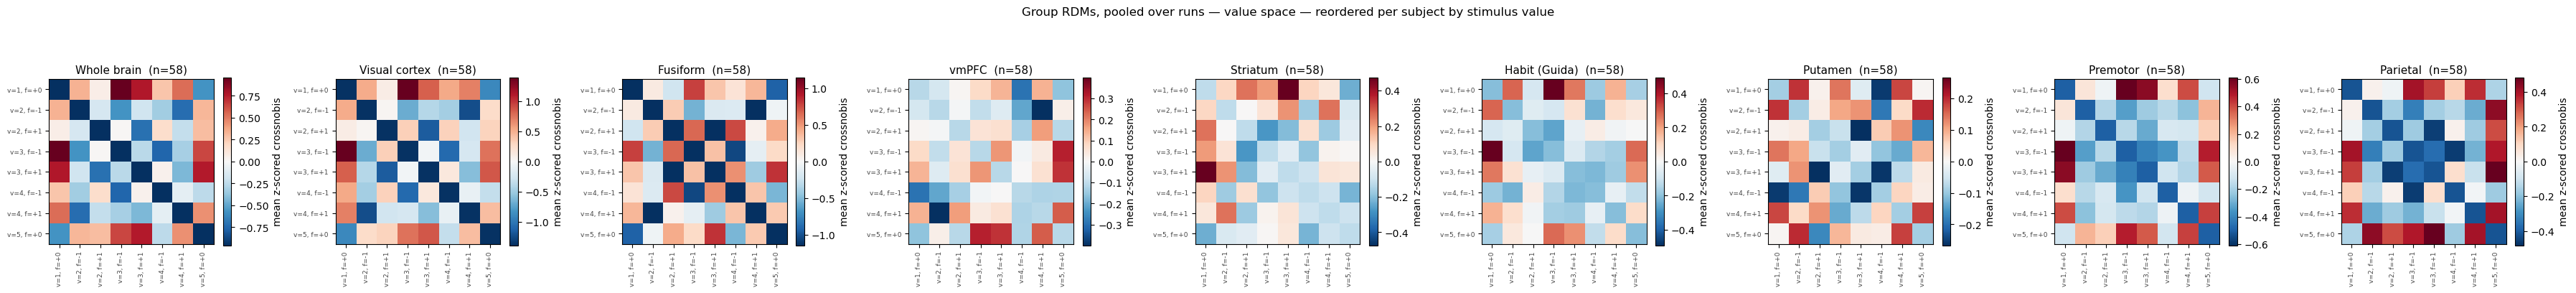

In [6]:
def _z_rdm(r):
    v = r[iu]
    return (r - v.mean()) / v.std() if v.std() > 0 else r - v.mean()


def group_rdm(mask, scope="pooled", space="image"):
    """Mean z-scored RDM across subjects, in image space or value space.

    Each subject's RDM is z-scored over its off-diagonal cells first so that subjects
    with globally larger distances do not dominate the average.
    """
    mats = load_rdms(RSA_DIR, mask, scope)
    stacked, order_labels = [], None
    for sub, r in mats.items():
        npz = model_rdms[sub]
        if space == "image":
            idx = np.argsort(npz["stim_names"])
            labs = [str(s) for s in npz["stim_names"][idx]]
        elif space == "value":
            # sort by (value, frequency) so every subject's rows line up by value
            idx = np.lexsort((npz["stim_frequency"], npz["stim_value"]))
            labs = [f"v={int(v)}, f={int(f):+d}" for v, f in
                    zip(npz["stim_value"][idx], npz["stim_frequency"][idx])]
        else:
            raise ValueError(space)
        if order_labels is None:
            order_labels = labs
        elif space == "value" and labs != order_labels:
            raise ValueError(f"{sub}: value ordering differs from the first subject — "
                             f"{labs} vs {order_labels}")
        stacked.append(_z_rdm(r)[np.ix_(idx, idx)])
    if not stacked:
        return None, None, 0
    return np.mean(stacked, axis=0), order_labels, len(stacked)


for space, blurb in [("image", "image space — structure here is visual, value is scrambled"),
                     ("value", "value space — reordered per subject by stimulus value")]:
    fig, axes = plt.subplots(1, len(MASKS), figsize=(4 * len(MASKS), 4.3))
    for ax, mask in zip(np.atleast_1d(axes), MASKS):
        g, labs, n = group_rdm(mask, "pooled", space)
        if g is None:
            ax.set_visible(False)
            continue
        lim = np.abs(g[iu]).max()
        im = ax.imshow(g, cmap="RdBu_r", vmin=-lim, vmax=lim)   # diverging, 0 = neutral
        ax.set_title(f"{MASK_LABELS[mask]}  (n={n})", fontsize=11)
        ax.set_xticks(range(8)); ax.set_yticks(range(8))
        ax.set_xticklabels(labs, rotation=90, fontsize=6.5, color="#444444")
        ax.set_yticklabels(labs, fontsize=6.5, color="#444444")
        fig.colorbar(im, ax=ax, fraction=0.046, label="mean z-scored crossnobis")
    fig.suptitle(f"Group RDMs, pooled over runs — {blurb}", fontsize=12)
    fig.tight_layout()
    plt.show()


subset = 'nonfigure'   scope = 'pooled'   model = 'objective'   (n = 58)
mask                        category                 value             frequency     second_stim_value           choice_rate
Whole brain          +0.035±0.043          -0.038±0.053          +0.203±0.038***       +0.084±0.055          -0.023±0.051   
Visual cortex        +0.036±0.045          -0.080±0.034*         +0.337±0.031***       +0.060±0.041          -0.120±0.043** 
Fusiform             +0.037±0.045          -0.118±0.033***       +0.373±0.034***       +0.159±0.040***       -0.049±0.043   
vmPFC                +0.014±0.034          -0.122±0.048*         -0.041±0.030          +0.035±0.058          -0.019±0.040   
Striatum             +0.042±0.028          +0.076±0.046          +0.091±0.035*         -0.059±0.054          +0.069±0.050   
Habit (Guida)        +0.060±0.035          +0.018±0.049          +0.055±0.032          +0.054±0.059          +0.078±0.051   
Putamen              +0.053±0.036          +0.024±0

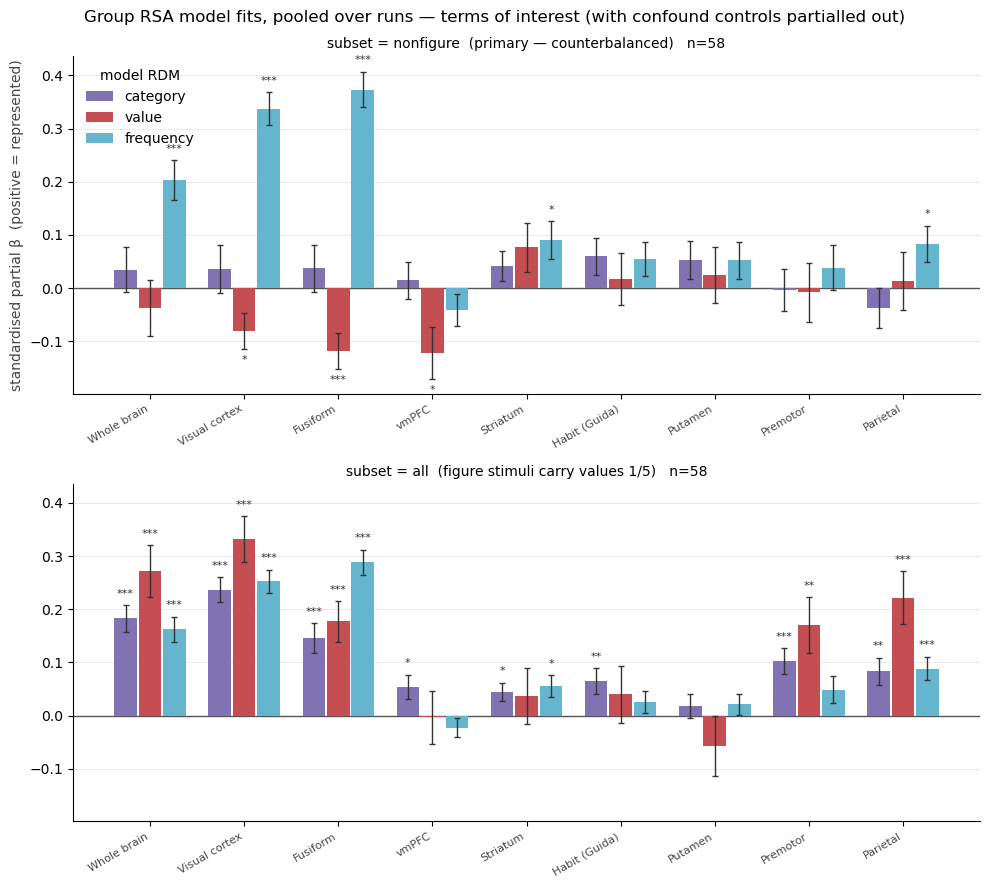

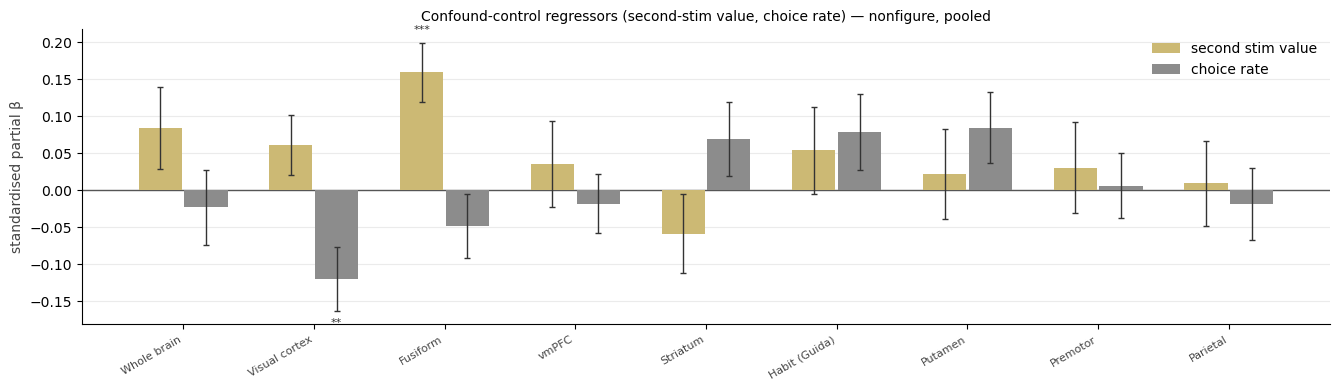

In [7]:
def beta_table(subset, model=PRIMARY_MODEL, scope="pooled", frame=None, terms=None):
    frame = df if frame is None else frame
    terms = MODEL_TERMS if terms is None else terms
    out = {}
    for term in terms:
        col = f"beta_{term}"
        if col not in frame.columns:
            continue
        s = summarise(frame, col, scope=scope, subset=subset, model=model)
        out[term] = s
    return out


for subset in ["nonfigure", "all"]:
    tabs = beta_table(subset)
    available = [t for t in MODEL_TERMS if t in tabs]
    print(f"\n{'='*100}\nsubset = {subset!r}   scope = 'pooled'   model = {PRIMARY_MODEL!r}"
          f"   (n = {tabs[available[0]]['n'].max():.0f})\n{'='*100}")
    print(f"{'mask':14s}" + "".join(f"{t:>22s}" for t in available))
    for mask in MASKS:
        cells = []
        for term in available:
            r = tabs[term].loc[mask]
            cells.append(f"{r['mean']:+.3f}±{r['sem']:.3f}{stars(r['p']):<3s}")
        print(f"{MASK_LABELS[mask]:14s}" + "".join(f"{c:>22s}" for c in cells))

# --- Main bar chart: terms of interest (cat/val/freq) ---
fig, axes = plt.subplots(2, 1, figsize=(10, 9), sharey=True)
for ax, subset in zip(axes, ["nonfigure", "all"]):
    tabs = beta_table(subset, terms=TERMS_OF_INTEREST)
    avail = [t for t in TERMS_OF_INTEREST if t in tabs]
    x = np.arange(len(MASKS)); w = 0.26
    for j, term in enumerate(avail):
        s = tabs[term].reindex(MASKS)
        off = (j - 1) * w
        ax.bar(x + off, s["mean"], width=w - 0.02, color=TERM_COLORS[term],
               label=term if ax is axes[0] else None, zorder=3)
        ax.errorbar(x + off, s["mean"], yerr=s["sem"], fmt="none", color="#333333",
                    capsize=2.5, linewidth=1, zorder=4)
        for xi, (m, p) in enumerate(zip(s["mean"], s["p"])):
            if stars(p):
                ax.text(xi + off, m + np.sign(m) * (s["sem"].iloc[xi] + .012), stars(p),
                        ha="center", va="bottom" if m >= 0 else "top",
                        fontsize=8, color="#333333")
    ax.axhline(0, color="#555555", linewidth=1, zorder=2)
    ax.set_xticks(x); ax.set_xticklabels([MASK_LABELS[m] for m in MASKS], rotation=30,
                                         ha="right", fontsize=8, color="#444444")
    n = int(tabs[avail[0]]["n"].max())
    ax.set_title(f"subset = {subset}"
                 f"{'  (primary — counterbalanced)' if subset=='nonfigure' else '  (figure stimuli carry values 1/5)'}"
                 f"   n={n}", fontsize=10)
    ax.grid(axis="y", alpha=.25, zorder=0); ax.set_axisbelow(True)
    for s_ in ("top", "right"):
        ax.spines[s_].set_visible(False)
axes[0].set_ylabel("standardised partial β  (positive = represented)", color="#444444")
axes[0].legend(frameon=False, loc="upper left", title="model RDM")
fig.suptitle("Group RSA model fits, pooled over runs — terms of interest (with confound controls partialled out)",
             fontsize=12)
fig.tight_layout()
plt.show()

# --- Confound-control regressors ---
CONFOUND_TERMS = ["second_stim_value", "choice_rate"]
confound_tabs = beta_table("nonfigure", terms=CONFOUND_TERMS)
avail_c = [t for t in CONFOUND_TERMS if t in confound_tabs]
if avail_c:
    fig, ax = plt.subplots(figsize=(max(9, 1.5 * len(MASKS)), 4))
    x = np.arange(len(MASKS)); w = 0.35
    for j, term in enumerate(avail_c):
        s = confound_tabs[term].reindex(MASKS)
        off = (j - 0.5) * w
        ax.bar(x + off, s["mean"], width=w - 0.02, color=TERM_COLORS[term],
               label=term.replace("_", " "), zorder=3)
        ax.errorbar(x + off, s["mean"], yerr=s["sem"], fmt="none", color="#333333",
                    capsize=2.5, linewidth=1, zorder=4)
        for xi, (m, p) in enumerate(zip(s["mean"], s["p"])):
            if stars(p):
                ax.text(xi + off, m + np.sign(m) * (s["sem"].iloc[xi] + .01), stars(p),
                        ha="center", va="bottom" if m >= 0 else "top",
                        fontsize=8, color="#333333")
    ax.axhline(0, color="#555555", linewidth=1, zorder=2)
    ax.set_xticks(x); ax.set_xticklabels([MASK_LABELS[m] for m in MASKS], rotation=30,
                                         ha="right", fontsize=8, color="#444444")
    ax.set_ylabel("standardised partial β", color="#444444")
    ax.set_title("Confound-control regressors (second-stim value, choice rate) — nonfigure, pooled",
                 fontsize=10)
    ax.legend(frameon=False, loc="best")
    ax.grid(axis="y", alpha=.25, zorder=0); ax.set_axisbelow(True)
    for s_ in ("top", "right"):
        ax.spines[s_].set_visible(False)
    fig.tight_layout()
    plt.show()
else:
    print("Confound-control columns not yet in data — rerun with updated run_rsa_roi.py.")

## 3a. FDR correction across the full test table

Benjamini-Hochberg applied to all ROI × term tests from the pooled/nonfigure/objective
slice. This is the minimum correction a reviewer would expect — it covers the primary
readout table only, not the per-run or model-variant extensions.

In [8]:
# Collect all p-values from the primary readout table (pooled, nonfigure, objective)
# across all ROIs and all MODEL_TERMS, then apply FDR.
fdr_rows = []
tabs_fdr = beta_table("nonfigure")
available_terms = [t for t in MODEL_TERMS if t in tabs_fdr]
for term in available_terms:
    s = tabs_fdr[term].reindex(MASKS)
    for mask in MASKS:
        fdr_rows.append(dict(mask=mask, term=term, p=s.loc[mask, "p"],
                             mean=s.loc[mask, "mean"], sem=s.loc[mask, "sem"]))

# Also include the same-value contrast
con_fdr = summarise(df, "contrast_value", scope="pooled", subset=PRIMARY_SUBSET)
for mask in MASKS:
    fdr_rows.append(dict(mask=mask, term="contrast_value", p=con_fdr.loc[mask, "p"],
                         mean=con_fdr.loc[mask, "mean"], sem=con_fdr.loc[mask, "sem"]))

fdr_df = pd.DataFrame(fdr_rows)
reject, pvals_corr, _, _ = multipletests(fdr_df["p"].values, alpha=0.05, method="fdr_bh")
fdr_df["p_fdr"] = pvals_corr
fdr_df["sig_fdr"] = reject

print(f"FDR correction (Benjamini-Hochberg) across {len(fdr_df)} tests "
      f"({len(MASKS)} ROIs × {len(available_terms)} terms + contrast)")
print(f"{'mask':14s}{'term':>20s}{'β':>8s}{'p_unc':>10s}{'p_fdr':>10s}{'sig':>5s}")
for _, r in fdr_df.sort_values(["term", "mask"]).iterrows():
    print(f"{MASK_LABELS[r['mask']]:14s}{r['term']:>20s}{r['mean']:>+8.3f}"
          f"{r['p']:>10.4f}{r['p_fdr']:>10.4f}{'  *' if r['sig_fdr'] else ''}")

n_sig_unc = (fdr_df.p < 0.05).sum()
n_sig_fdr = fdr_df.sig_fdr.sum()
print(f"\n{n_sig_unc} tests significant uncorrected, {n_sig_fdr} survive FDR at q=0.05")

FDR correction (Benjamini-Hochberg) across 54 tests (9 ROIs × 5 terms + contrast)
mask                          term       β     p_unc     p_fdr  sig
Fusiform                  category  +0.037    0.4096    0.6703
Habit (Guida)             category  +0.060    0.0931    0.3142
Parietal                  category  -0.037    0.3260    0.6288
Premotor                  category  -0.004    0.9194    0.9194
Putamen                   category  +0.053    0.1389    0.3324
Striatum                  category  +0.042    0.1388    0.3324
Visual cortex             category  +0.036    0.4216    0.6703
vmPFC                     category  +0.014    0.6755    0.8082
Whole brain               category  +0.035    0.4198    0.6703
Fusiform               choice_rate  -0.049    0.2589    0.5377
Habit (Guida)          choice_rate  +0.078    0.1331    0.3324
Parietal               choice_rate  -0.019    0.6968    0.8082
Premotor               choice_rate  +0.006    0.8997    0.9167
Putamen                choice_r

## 4. The targeted contrast

Among pairs that are all different-identity and all different-category: are those sharing a
reward level more similar? This is the readout that most directly escapes the identity
confound. Only 3 same-value cells per subject, so the group test is the only meaningful
level.

contrast_value — pooled, subset='nonfigure'  (positive = value coding)

mask             n     mean     sem       t         p   p(wilcox)
Whole brain     58   -0.202   0.077   -2.62    0.0112*     0.0094
Visual cortex   58   -0.519   0.055   -9.45    0.0000***   0.0000
Fusiform        58   -0.637   0.052  -12.29    0.0000***   0.0000
vmPFC           58   -0.062   0.076   -0.81    0.4220      0.5030
Striatum        58   +0.034   0.065    0.53    0.6005      0.6395
Habit (Guida)   58   -0.027   0.066   -0.41    0.6849      0.5693
Putamen         58   -0.060   0.084   -0.71    0.4790      0.2941
Premotor        58   -0.020   0.072   -0.28    0.7793      0.6121
Parietal        58   -0.033   0.070   -0.48    0.6325      0.6175


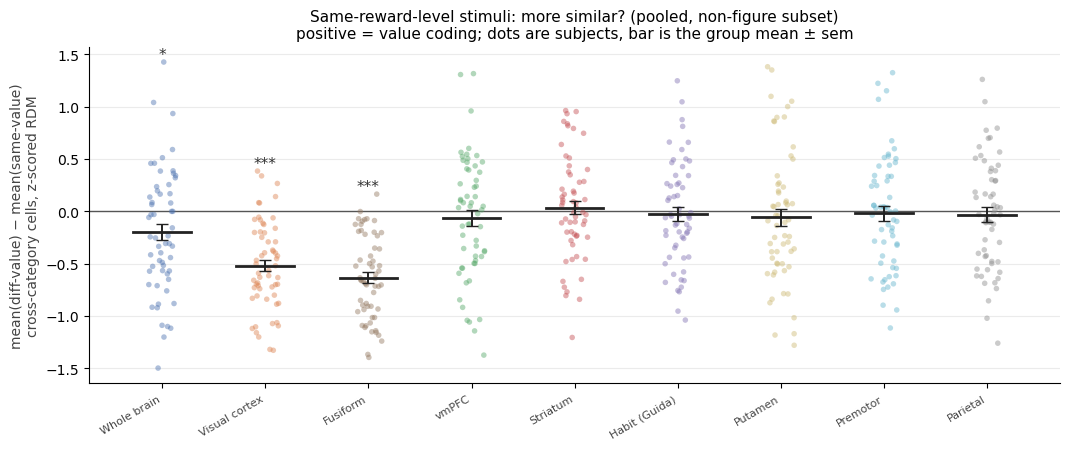

In [9]:
con = summarise(df, "contrast_value", scope="pooled", subset=PRIMARY_SUBSET)
print(f"contrast_value — pooled, subset={PRIMARY_SUBSET!r}  (positive = value coding)\n")
print(f"{'mask':14s}{'n':>4s}{'mean':>9s}{'sem':>8s}{'t':>8s}{'p':>10s}{'p(wilcox)':>12s}")
for mask in MASKS:
    r = con.loc[mask]
    print(f"{MASK_LABELS[mask]:14s}{r['n']:>4.0f}{r['mean']:>+9.3f}{r['sem']:>8.3f}"
          f"{r['t']:>8.2f}{r['p']:>10.4f}{stars(r['p']):<3s}{r['p_wilcoxon']:>9.4f}")

# Per-subject distribution behind each group mean — never show only the bar.
fig, ax = plt.subplots(figsize=(max(8.5, 1.2 * len(MASKS)), 4.6))
sel = df[(df.scope == "pooled") & (df["subset"] == PRIMARY_SUBSET) & (df.model == PRIMARY_MODEL)]
for i, mask in enumerate(MASKS):
    v = sel.loc[sel["mask"] == mask, "contrast_value"].dropna().values
    ax.scatter(np.full(len(v), i) + np.random.uniform(-.13, .13, len(v)), v,
               s=16, color=COLORS[mask], alpha=.45, edgecolor="none", zorder=3)
    r = con.loc[mask]
    ax.plot([i - .28, i + .28], [r["mean"]] * 2, color="#222222", linewidth=2, zorder=5)
    ax.errorbar(i, r["mean"], yerr=r["sem"], fmt="none", color="#222222",
                capsize=4, linewidth=1.4, zorder=5)
    if stars(r["p"]):
        ax.text(i, v.max() if len(v) else 0, stars(r["p"]), ha="center", va="bottom",
                fontsize=11, color="#333333")
ax.axhline(0, color="#555555", linewidth=1, zorder=2)
ax.set_xticks(range(len(MASKS)))
ax.set_xticklabels([MASK_LABELS[m] for m in MASKS], rotation=30, ha="right",
                   fontsize=8, color="#444444")
ax.set_ylabel("mean(diff-value) − mean(same-value)\ncross-category cells, z-scored RDM",
              color="#444444")
ax.set_title("Same-reward-level stimuli: more similar? (pooled, non-figure subset)\n"
             "positive = value coding; dots are subjects, bar is the group mean ± sem",
             fontsize=11)
ax.grid(axis="y", alpha=.25, zorder=0); ax.set_axisbelow(True)
for s_ in ("top", "right"):
    ax.spines[s_].set_visible(False)
fig.tight_layout()
plt.show()

## 5. Learning dynamics

Per-run RDMs (within-run 2-fold CV). Look for value structure rising learning1 → learning2,
and persisting into `test`, which has **no feedback** — persistence there is the habit-relevant
claim.

These rest on half the trials and 2 folds instead of 3, so they are much noisier than pooled.
`crossnobis_validation.ipynb` §4 shows the two split modes diverge badly at low SNR — treat a
marginal result here as provisional until it reproduces under `--within-run-split blocked`.


β(objective value)  —  subset='nonfigure'
mask                     learning1           learning2                test
Whole brain        -0.038±0.039        +0.004±0.049        +0.040±0.066   
Visual cortex      -0.088±0.038*       -0.081±0.048        +0.009±0.056   
Fusiform           -0.175±0.031***     -0.194±0.043***     +0.120±0.066   
vmPFC              -0.054±0.042        +0.057±0.049        -0.104±0.052*  
Striatum           -0.019±0.040        +0.070±0.051        +0.071±0.055   
Habit (Guida)      -0.031±0.038        +0.063±0.049        +0.004±0.070   
Putamen            +0.020±0.047        +0.064±0.044        -0.003±0.064   
Premotor           -0.048±0.044        +0.032±0.046        +0.037±0.063   
Parietal           +0.026±0.047        -0.013±0.046        +0.080±0.069   



β(RL Q-value)  —  subset='nonfigure'


mask                     learning1           learning2                test
Whole brain        -0.022±0.037        +0.003±0.049        +0.040±0.066   
Visual cortex      -0.090±0.036*       -0.083±0.048        +0.009±0.056   
Fusiform           -0.147±0.028***     -0.194±0.043***     +0.120±0.066   
vmPFC              -0.045±0.043        +0.057±0.049        -0.104±0.052   
Striatum           +0.010±0.043        +0.068±0.052        +0.071±0.055   
Habit (Guida)      -0.029±0.037        +0.064±0.049        +0.005±0.070   
Putamen            +0.003±0.045        +0.066±0.044        -0.003±0.065   
Premotor           -0.041±0.043        +0.031±0.046        +0.038±0.063   
Parietal           +0.035±0.043        -0.017±0.046        +0.081±0.069   

same-value contrast  —  subset='nonfigure'
mask                     learning1           learning2                test
Whole brain        -0.108±0.062        -0.141±0.061*       +0.074±0.056   
Visual cortex      -0.301±0.053***     -0.244±0.063*** 

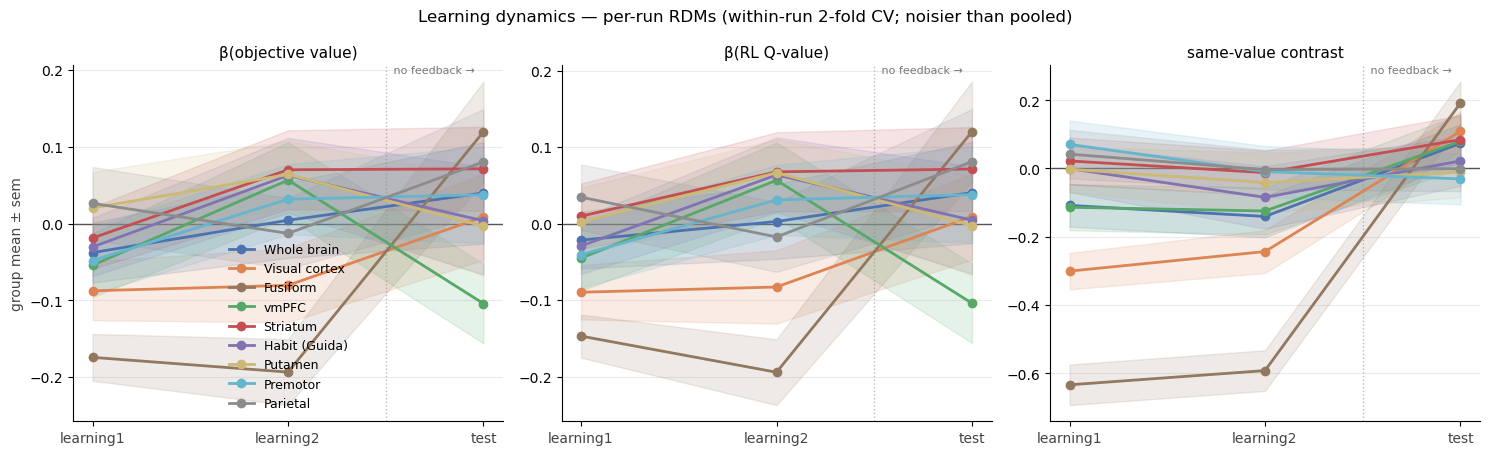

In [10]:
def dynamics(column, model=PRIMARY_MODEL, subset=PRIMARY_SUBSET):
    """(mask x run_scope) group mean/sem/p of `column`."""
    out = {}
    for mask in MASKS:
        out[mask] = {sc: group_test(
            df[(df.scope == sc) & (df["subset"] == subset) & (df.model == model) &
               (df["mask"] == mask)][column].values) for sc in RUN_SCOPES}
    return out


for column, model, title in [
        ("beta_value", "objective", "β(objective value)"),
        ("beta_value", "rl", "β(RL Q-value)"),
        ("contrast_value", "objective", "same-value contrast")]:
    d = dynamics(column, model=model)
    print(f"\n{title}  —  subset={PRIMARY_SUBSET!r}")
    print(f"{'mask':14s}" + "".join(f"{s:>20s}" for s in RUN_SCOPES))
    for mask in MASKS:
        cells = [f"{d[mask][s]['mean']:+.3f}±{d[mask][s]['sem']:.3f}{stars(d[mask][s]['p']):<3s}"
                 for s in RUN_SCOPES]
        print(f"{MASK_LABELS[mask]:14s}" + "".join(f"{c:>20s}" for c in cells))

# One line per ROI across the three runs. Color follows the ROI (the entity), not rank.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharex=True)
panels = [("beta_value", "objective", "β(objective value)"),
          ("beta_value", "rl", "β(RL Q-value)"),
          ("contrast_value", "objective", "same-value contrast")]
x = np.arange(len(RUN_SCOPES))
for ax, (column, model, title) in zip(axes, panels):
    d = dynamics(column, model=model)
    for mask in MASKS:
        m = np.array([d[mask][s]["mean"] for s in RUN_SCOPES])
        e = np.array([d[mask][s]["sem"] for s in RUN_SCOPES])
        ax.plot(x, m, marker="o", markersize=6, linewidth=2, color=COLORS[mask],
                label=MASK_LABELS[mask] if ax is axes[0] else None, zorder=3)
        ax.fill_between(x, m - e, m + e, color=COLORS[mask], alpha=.15, zorder=2)
    ax.axhline(0, color="#555555", linewidth=1, zorder=1)
    ax.axvline(1.5, color="#BBBBBB", linewidth=1, linestyle=":", zorder=1)
    ax.text(1.52, ax.get_ylim()[1], " no feedback →", fontsize=8, color="#777777",
            va="top", ha="left")
    ax.set_xticks(x); ax.set_xticklabels(RUN_SCOPES, color="#444444")
    ax.set_title(title, fontsize=11)
    ax.grid(axis="y", alpha=.25, zorder=0); ax.set_axisbelow(True)
    for s_ in ("top", "right"):
        ax.spines[s_].set_visible(False)
axes[0].set_ylabel("group mean ± sem", color="#444444")
axes[0].legend(frameon=False, fontsize=9, loc="best")
fig.suptitle("Learning dynamics — per-run RDMs (within-run 2-fold CV; noisier than pooled)",
             fontsize=12)
fig.tight_layout()
plt.show()

## 5b. Does beta(frequency) grow across runs, as choice-frequency accumulates? (2026-09-03)

The +-1 choice-frequency label is a fixed per-subject design assignment (same regressor
value in every scope), but the *behavioural* divergence it names accumulates over the
session — early in `learning1` the subject has barely started diverging in how often they
choose the two stimulus classes, so if the neural geometry tracks the actual accumulated
choice history (not just the nominal design label), beta(frequency) should be small in
`learning1` and grow through `learning2` into `test`. Reuses the `dynamics()` helper from
§5 (same per-run-scope machinery already used for the value dynamics panels).

beta(frequency) across runs  —  subset='nonfigure'
mask                     learning1           learning2                test
Whole brain        +0.060±0.035        +0.114±0.037**      -0.041±0.039   
Visual cortex      +0.212±0.037***     +0.180±0.040***     -0.018±0.039   
Fusiform           +0.364±0.039***     +0.278±0.043***     -0.054±0.038   
vmPFC              +0.006±0.031        +0.099±0.030**      -0.029±0.042   
Striatum           -0.078±0.032*       +0.006±0.036        +0.030±0.040   
Habit (Guida)      -0.002±0.034        +0.047±0.036        +0.050±0.041   
Putamen            +0.023±0.039        +0.054±0.039        +0.037±0.034   
Premotor           -0.039±0.035        +0.011±0.035        -0.017±0.032   
Parietal           +0.012±0.037        +0.032±0.040        -0.017±0.040   

paired t-test, beta_frequency: learning1 vs. later runs (visual cortex, fusiform):
  Visual cortex: learning2-learning1 t=-0.74 p=0.4629   test-learning1 t=-4.39 p=0.0000   (n=58)
  Fusiform: learni

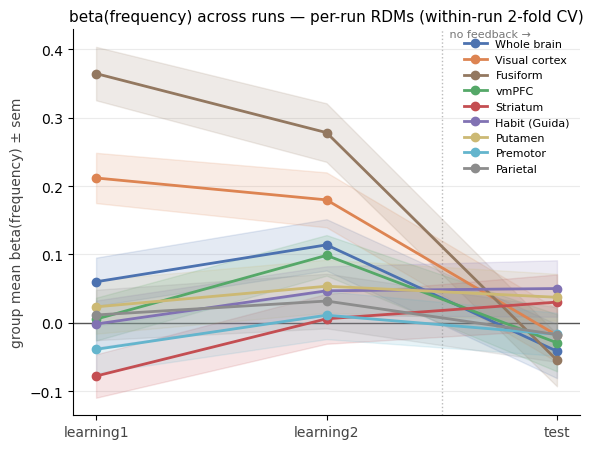

In [11]:
d_freq = dynamics("beta_frequency", model=PRIMARY_MODEL)
print(f"beta(frequency) across runs  —  subset={PRIMARY_SUBSET!r}")
print(f"{'mask':14s}" + "".join(f"{s:>20s}" for s in RUN_SCOPES))
for mask in MASKS:
    cells_ = [f"{d_freq[mask][s]['mean']:+.3f}\u00b1{d_freq[mask][s]['sem']:.3f}"
             f"{stars(d_freq[mask][s]['p']):<3s}" for s in RUN_SCOPES]
    print(f"{MASK_LABELS[mask]:14s}" + "".join(f"{c:>20s}" for c in cells_))

# Pairwise test: is learning1 smaller than learning2/test specifically?
print("\npaired t-test, beta_frequency: learning1 vs. later runs (visual cortex, fusiform):")
for mask in ["visualcortex", "fusiform"]:
    l1 = df[(df.scope == "learning1") & (df["subset"] == PRIMARY_SUBSET) &
           (df.model == PRIMARY_MODEL) & (df["mask"] == mask)].set_index("subject")["beta_frequency"]
    l2 = df[(df.scope == "learning2") & (df["subset"] == PRIMARY_SUBSET) &
           (df.model == PRIMARY_MODEL) & (df["mask"] == mask)].set_index("subject")["beta_frequency"]
    te = df[(df.scope == "test") & (df["subset"] == PRIMARY_SUBSET) &
           (df.model == PRIMARY_MODEL) & (df["mask"] == mask)].set_index("subject")["beta_frequency"]
    common = l1.index.intersection(l2.index).intersection(te.index)
    l1c, l2c, tec = l1.loc[common], l2.loc[common], te.loc[common]
    t12, p12 = stats.ttest_rel(l2c, l1c, nan_policy="omit")
    t1t, p1t = stats.ttest_rel(tec, l1c, nan_policy="omit")
    print(f"  {MASK_LABELS[mask]}: learning2-learning1 t={t12:.2f} p={p12:.4f}   "
         f"test-learning1 t={t1t:.2f} p={p1t:.4f}   (n={len(common)})")

fig, ax = plt.subplots(figsize=(6, 4.6))
x = np.arange(len(RUN_SCOPES))
for mask in MASKS:
    m = np.array([d_freq[mask][s]["mean"] for s in RUN_SCOPES])
    e = np.array([d_freq[mask][s]["sem"] for s in RUN_SCOPES])
    ax.plot(x, m, marker="o", markersize=6, linewidth=2, color=COLORS[mask],
           label=MASK_LABELS[mask], zorder=3)
    ax.fill_between(x, m - e, m + e, color=COLORS[mask], alpha=.15, zorder=2)
ax.axhline(0, color="#555555", linewidth=1, zorder=1)
ax.axvline(1.5, color="#BBBBBB", linewidth=1, linestyle=":", zorder=1)
ax.text(1.52, ax.get_ylim()[1], " no feedback \u2192", fontsize=8, color="#777777",
       va="top", ha="left")
ax.set_xticks(x); ax.set_xticklabels(RUN_SCOPES, color="#444444")
ax.set_ylabel("group mean beta(frequency) \u00b1 sem", color="#444444")
ax.set_title("beta(frequency) across runs \u2014 per-run RDMs (within-run 2-fold CV)",
            fontsize=11)
ax.legend(frameon=False, fontsize=8, loc="best")
ax.grid(axis="y", alpha=.25, zorder=0); ax.set_axisbelow(True)
for s_ in ("top", "right"):
    ax.spines[s_].set_visible(False)
fig.tight_layout()
plt.show()


## 6. Negative control — shuffled labels

End-to-end version of `crossnobis_validation.ipynb` §2, on real data. Everything should
collapse to ~0. Generate with:

```bash
SHUFFLE_SEED=1 OUTPUT_DIR=.../derivatives/rsa_shuffled bash multivariate/submit_rsa_roi.sh
```

Also checks `rdm_mean` straddles 0 under the shuffle (the unbiasedness property on real
data) and that the RDM diagonal is exactly 0.

real (n=58)  vs  shuffled (n=58)   pooled, subset='nonfigure'

mask          term                          real          shuffled
Whole brain   category               +0.035            -0.013     
Whole brain   value                  -0.038            -0.016     
Whole brain   frequency              +0.203***         -0.002     
Whole brain   second_stim_value       +0.084            +0.126*    
Whole brain   choice_rate            -0.023            +0.006     
Visual cortex category               +0.036            +0.049     
Visual cortex value                  -0.080*           -0.036     
Visual cortex frequency              +0.337***         -0.040     
Visual cortex second_stim_value       +0.060            +0.039     
Visual cortex choice_rate            -0.120**          +0.028     


Fusiform      category               +0.037            -0.010     
Fusiform      value                  -0.118***         -0.074*    
Fusiform      frequency              +0.373***         -0.022     
Fusiform      second_stim_value       +0.159***         +0.046     
Fusiform      choice_rate            -0.049            +0.056     
vmPFC         category               +0.014            -0.015     


vmPFC         value                  -0.122*           +0.056     
vmPFC         frequency              -0.041            -0.014     
vmPFC         second_stim_value       +0.035            +0.067     
vmPFC         choice_rate            -0.019            -0.090     
Striatum      category               +0.042            -0.015     
Striatum      value                  +0.076            +0.016     
Striatum      frequency              +0.091*           -0.028     
Striatum      second_stim_value       -0.059            +0.051     
Striatum      choice_rate            +0.069            +0.024     
Habit (Guida) category               +0.060            +0.009     
Habit (Guida) value                  +0.018            +0.020     


Habit (Guida) frequency              +0.055            +0.033     
Habit (Guida) second_stim_value       +0.054            +0.046     
Habit (Guida) choice_rate            +0.078            +0.097     
Putamen       category               +0.053            +0.018     
Putamen       value                  +0.024            +0.040     
Putamen       frequency              +0.052            +0.039     


Putamen       second_stim_value       +0.022            -0.034     
Putamen       choice_rate            +0.084            +0.078     
Premotor      category               -0.004            -0.023     
Premotor      value                  -0.008            +0.016     
Premotor      frequency              +0.038            -0.023     
Premotor      second_stim_value       +0.030            +0.090     
Premotor      choice_rate            +0.006            -0.016     
Parietal      category               -0.037            -0.012     
Parietal      value                  +0.014            -0.003     
Parietal      frequency              +0.083*           +0.013     
Parietal      second_stim_value       +0.009            +0.078     
Parietal      choice_rate            -0.019            +0.038     


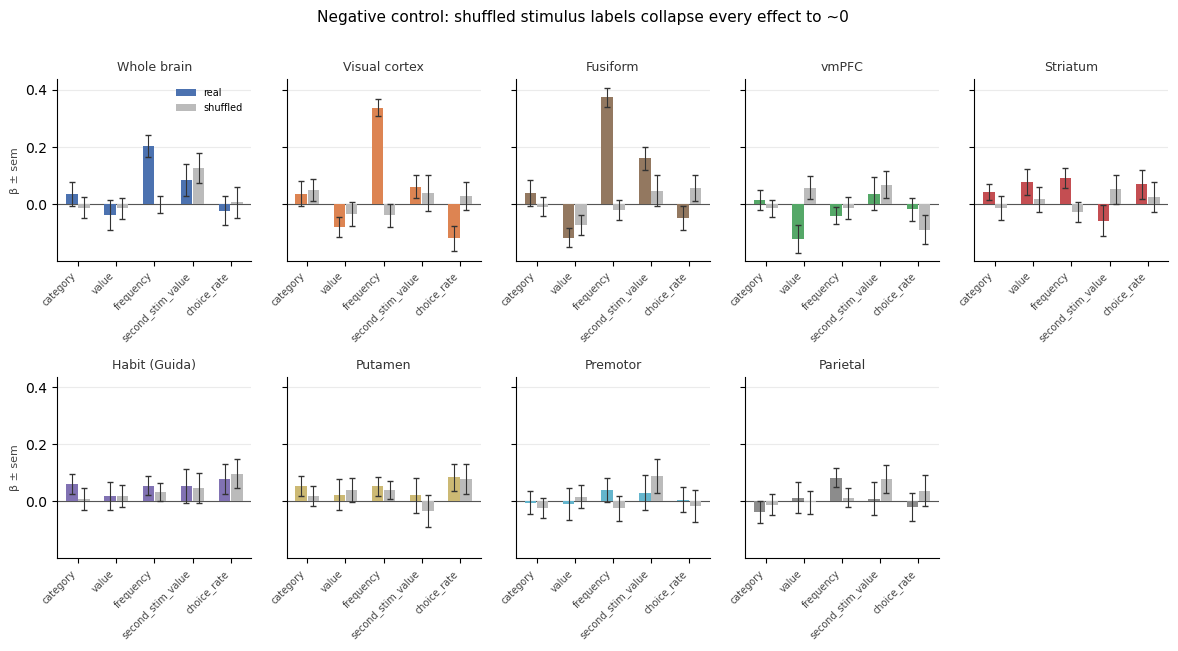


mean raw crossnobis distance (rdm_mean) — shuffled should straddle 0:
  Whole brain    real +0.00659   shuffled -0.00051
  Visual cortex  real +0.02768   shuffled -0.00055
  Fusiform       real +0.05207   shuffled -0.00101
  vmPFC          real +0.00293   shuffled -0.00023
  Striatum       real +0.00258   shuffled -0.00096
  Habit (Guida)  real +0.00191   shuffled -0.00059
  Putamen        real +0.00143   shuffled -0.00063
  Premotor       real +0.00464   shuffled -0.00037
  Parietal       real +0.00571   shuffled -0.00100

max |diagonal| over subjects (must be 0): 0.0


In [12]:
if not len(df_shuf):
    print(f"No shuffled control found at {RSA_SHUFFLED_DIR} — see the cell above to generate it.")
else:
    cols = [f"beta_{t}" for t in MODEL_TERMS]
    col_labels = [t.replace("beta_", "") for t in cols]
    print(f"real (n={df.subject.nunique()})  vs  shuffled (n={df_shuf.subject.nunique()})"
          f"   pooled, subset={PRIMARY_SUBSET!r}\n")
    print(f"{'mask':14s}{'term':16s}{'real':>18s}{'shuffled':>18s}")
    for mask in MASKS:
        for c in cols:
            r = summarise(df, c, subset=PRIMARY_SUBSET).loc[mask]
            s = summarise(df_shuf, c, subset=PRIMARY_SUBSET).loc[mask]
            print(f"{MASK_LABELS[mask]:14s}{c.replace('beta_',''):16s}"
                  f"{r['mean']:>+13.3f}{stars(r['p']):<5s}"
                  f"{s['mean']:>+13.3f}{stars(s['p']):<5s}")

    # --- Grid layout: one subplot per mask ---
    n_masks = len(MASKS)
    ncols_grid = 5
    nrows_grid = (n_masks + ncols_grid - 1) // ncols_grid
    fig, axes_grid = plt.subplots(nrows_grid, ncols_grid,
                                  figsize=(12, 3.2 * nrows_grid),
                                  sharey=True)
    axes_flat = axes_grid.flatten()
    w = .32

    for i, mask in enumerate(MASKS):
        ax = axes_flat[i]
        x = np.arange(len(cols))
        for j, c in enumerate(cols):
            r = summarise(df, c, subset=PRIMARY_SUBSET).loc[mask]
            s = summarise(df_shuf, c, subset=PRIMARY_SUBSET).loc[mask]
            ax.bar(j - w/2, r["mean"], width=w - .02, color=COLORS[mask], zorder=3,
                   label="real" if (i == 0 and j == 0) else None)
            ax.bar(j + w/2, s["mean"], width=w - .02, color="#BBBBBB", zorder=3,
                   label="shuffled" if (i == 0 and j == 0) else None)
            ax.errorbar([j - w/2, j + w/2], [r["mean"], s["mean"]],
                        yerr=[r["sem"], s["sem"]], fmt="none", color="#333333",
                        capsize=2, linewidth=.8, zorder=4)
        ax.axhline(0, color="#555555", linewidth=.8, zorder=2)
        ax.set_xticks(x)
        ax.set_xticklabels(col_labels, rotation=45, ha="right", fontsize=7, color="#444444")
        ax.set_title(MASK_LABELS[mask], fontsize=9, color="#333333")
        ax.grid(axis="y", alpha=.25, zorder=0); ax.set_axisbelow(True)
        for s_ in ("top", "right"):
            ax.spines[s_].set_visible(False)

    # Hide unused subplots
    for k in range(n_masks, len(axes_flat)):
        axes_flat[k].set_visible(False)

    # Add legend to first subplot
    axes_flat[0].legend(frameon=False, fontsize=7, loc="upper right")
    # Y-label on left column
    for r in range(nrows_grid):
        axes_flat[r * ncols_grid].set_ylabel("β ± sem", fontsize=8, color="#444444")
    fig.suptitle("Negative control: shuffled stimulus labels collapse every effect to ~0",
                 fontsize=11, y=1.01)
    fig.tight_layout()
    plt.show()

# Unbiasedness + diagonal checks
print("\nmean raw crossnobis distance (rdm_mean) — shuffled should straddle 0:")
for mask in MASKS:
    q = lambda f, m=mask: f[(f.scope == "pooled") & (f["subset"] == "all") &
                    (f.model == PRIMARY_MODEL) & (f["mask"] == m)].rdm_mean
    real_m = q(df).mean()
    shuf_m = q(df_shuf).mean() if len(df_shuf) else np.nan
    print(f"  {MASK_LABELS[mask]:14s} real {real_m:+.5f}   shuffled {shuf_m:+.5f}")

diags = [np.abs(np.diag(r)).max() for r in load_rdms(RSA_DIR, "visualcortex", "pooled").values()]
print(f"\nmax |diagonal| over subjects (must be 0): {max(diags) if diags else float('nan')}")


### 6a. Same-value contrast under shuffling

Split out from §6 above: `contrast_value` isn't one of the 5 regression terms — it's a targeted contrast on a small, structurally special subset (the 3 same-value pairs, which are also the 3 max-|Δfrequency| pairs by design; design-checks §3). Shown on its own so it isn't read as a 6th independent negative-control term alongside category/value/frequency/second_stim_value/choice_rate.

contrast_value — real (n=58) vs shuffled (n=58)   pooled, subset='nonfigure'

mask                        real          shuffled
Whole brain          -0.202*           -0.019     
Visual cortex        -0.519***         -0.044     
Fusiform             -0.637***         -0.204*    
vmPFC                -0.062            +0.067     
Striatum             +0.034            -0.031     
Habit (Guida)        -0.027            +0.008     
Putamen              -0.060            -0.007     
Premotor             -0.020            -0.034     
Parietal             -0.033            +0.011     


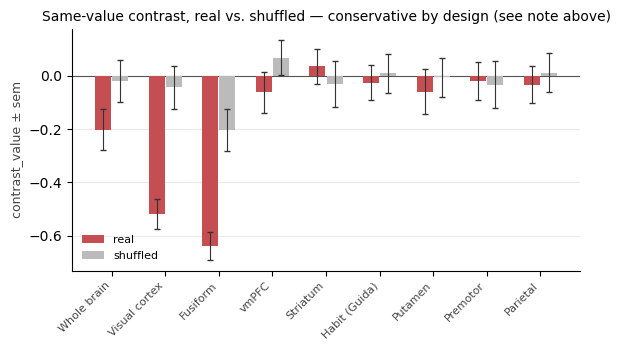

In [13]:
if len(df_shuf):
    print(f"contrast_value — real (n={df.subject.nunique()}) vs shuffled (n={df_shuf.subject.nunique()})"
          f"   pooled, subset={PRIMARY_SUBSET!r}\n")
    print(f"{'mask':14s}{'real':>18s}{'shuffled':>18s}")

    fig, ax = plt.subplots(figsize=(6, 3.6))
    x = np.arange(len(MASKS)); w = .32
    for i, mask in enumerate(MASKS):
        r = summarise(df, "contrast_value", subset=PRIMARY_SUBSET).loc[mask]
        s = summarise(df_shuf, "contrast_value", subset=PRIMARY_SUBSET).loc[mask]
        print(f"{MASK_LABELS[mask]:14s}{r['mean']:>+13.3f}{stars(r['p']):<5s}"
              f"{s['mean']:>+13.3f}{stars(s['p']):<5s}")
        ax.bar(i - w/2, r["mean"], width=w - .02, color="#C44E52", zorder=3,
               label="real" if i == 0 else None)
        ax.bar(i + w/2, s["mean"], width=w - .02, color="#BBBBBB", zorder=3,
               label="shuffled" if i == 0 else None)
        ax.errorbar([i - w/2, i + w/2], [r["mean"], s["mean"]],
                    yerr=[r["sem"], s["sem"]], fmt="none", color="#333333",
                    capsize=2, linewidth=.8, zorder=4)
    ax.axhline(0, color="#555555", linewidth=.8, zorder=2)
    ax.set_xticks(x)
    ax.set_xticklabels([MASK_LABELS[m] for m in MASKS], rotation=45, ha="right",
                       fontsize=8, color="#444444")
    ax.set_ylabel("contrast_value ± sem", fontsize=9, color="#444444")
    ax.set_title("Same-value contrast, real vs. shuffled — conservative by design (see note above)",
                 fontsize=10)
    ax.legend(frameon=False, fontsize=8, loc="best")
    ax.grid(axis="y", alpha=.25, zorder=0); ax.set_axisbelow(True)
    for s_ in ("top", "right"):
        ax.spines[s_].set_visible(False)
    fig.tight_layout()
    plt.show()
else:
    print("No shuffled control found — see §6 above.")


## 7. Robustness controls — amplitude confound and split mode

Two follow-up runs (jobs 5331516 / 5331517):

- **remove-mean** (`derivatives/rsa_remove_mean`): each trial pattern's spatial mean
  subtracted before crossnobis. Presentations are equal across the frequency label (§1b),
  so classic repetition suppression is not a candidate confound here — but a
  *choice-related* global-gain difference is (e.g. attention or motor preparation being
  stronger for frequently-chosen stimuli, scaling the whole response uniformly with no
  shared geometry). If that were driving the effect, it would collapse under remove-mean.
  The amplitude CSVs give the direct test too: amplitude ~ choice-frequency across stimuli.
- **blocked split** (`derivatives/rsa_blocked`): per-run RDMs re-estimated with
  first-half/second-half folds instead of interleaved. Any per-run result that doesn't
  reproduce across split modes is noise (`crossnobis_validation.ipynb` §4).

In [14]:
df_rm = load_results(DERIV_DIR / "rsa_remove_mean")
df_bl = load_results(DERIV_DIR / "rsa_blocked")

if not len(df_rm) or not len(df_bl):
    print("Control runs not found — see the cell above to generate them.")
else:
    # --- (a) does beta_frequency survive remove-mean? ------------------------
    print("=== (a) beta_frequency, pooled / nonfigure: original vs remove-mean ===")
    print(f"{'mask':14s}{'original':>16s}{'remove-mean':>16s}")
    for mask in MASKS:
        r = summarise(df, "beta_frequency").loc[mask]
        m = summarise(df_rm, "beta_frequency").loc[mask]
        print(f"{MASK_LABELS[mask]:14s}{r['mean']:>+13.3f}{stars(r['p']):<3s}"
              f"{m['mean']:>+13.3f}{stars(m['p']):<3s}")

    print("\nbeta_value and contrast_value under remove-mean:")
    for mask in MASKS:
        v = summarise(df_rm, "beta_value").loc[mask]
        c = summarise(df_rm, "contrast_value").loc[mask]
        print(f"{MASK_LABELS[mask]:14s} value {v['mean']:+.3f}{stars(v['p']):<3s}"
              f"   contrast {c['mean']:+.3f}{stars(c['p']):<3s}")

    # --- (a2) the direct amplitude ~ frequency test (adaptation signature) ----
    amp_files = sorted((DERIV_DIR / "rsa_remove_mean").glob("sub-*/sub-*_rsa_amplitude.csv"))
    amps = pd.concat([pd.read_csv(f).assign(subject=f.parent.name) for f in amp_files],
                     ignore_index=True)
    frq_map = {(s, str(n)): float(fq) for s, z in model_rdms.items()
               for n, fq in zip(z["stim_names"], z["stim_frequency"])}
    amps["frequ"] = [frq_map[(s, n)] for s, n in zip(amps.subject, amps.stim_name)]

    print("\n=== (a2) amplitude ~ frequency across stimuli (per-subject r, tested vs 0) ===")
    print(f"{'mask':14s}{'mean r':>10s}{'p':>10s}   high-minus-low amp (p)")
    for mask in MASKS:
        a = amps[amps["mask"] == mask]
        rs = a.groupby("subject").apply(
            lambda g: np.corrcoef(g.mean_amp, g.frequ)[0, 1], include_groups=False)
        t, p = stats.ttest_1samp(rs, 0)
        d = (a[a.frequ == 1].groupby("subject").mean_amp.mean()
             - a[a.frequ == -1].groupby("subject").mean_amp.mean())
        td, pd_ = stats.ttest_1samp(d, 0)
        print(f"{MASK_LABELS[mask]:14s}{rs.mean():>+10.3f}{p:>10.4f}   "
              f"{d.mean():+.4f} (p={pd_:.4f})")

    # --- (b) does the test-run sign flip reproduce under blocked split? -------
    print("\n=== (b) same-value contrast per run: interleaved vs blocked ===")
    print(f"{'mask':14s}" + "".join(f"{s:>14s}" for s in RUN_SCOPES) + "   |"
          + "".join(f"{s:>14s}" for s in RUN_SCOPES))
    print(f"{'':14s}{'-- interleaved --':>42s}   |{'-- blocked --':>42s}")
    for mask in MASKS:
        cells = []
        for frame in (df, df_bl):
            for sc in RUN_SCOPES:
                r = summarise(frame, "contrast_value", scope=sc).loc[mask]
                cells.append(f"{r['mean']:+.3f}{stars(r['p']):<3s}")
        print(f"{MASK_LABELS[mask]:14s}" + "".join(f"{c:>14s}" for c in cells[:3])
              + "   |" + "".join(f"{c:>14s}" for c in cells[3:]))

=== (a) beta_frequency, pooled / nonfigure: original vs remove-mean ===
mask                  original     remove-mean
Whole brain          +0.203***       +0.207***
Visual cortex        +0.337***       +0.375***
Fusiform             +0.373***       +0.420***
vmPFC                -0.041          -0.005   
Striatum             +0.091*         +0.093*  
Habit (Guida)        +0.055          +0.049   
Putamen              +0.052          +0.057   
Premotor             +0.038          +0.036   
Parietal             +0.083*         +0.071*  

beta_value and contrast_value under remove-mean:
Whole brain    value -0.035      contrast -0.198*  
Visual cortex  value -0.074*     contrast -0.570***
Fusiform       value -0.099**    contrast -0.675***
vmPFC          value -0.075      contrast -0.071   
Striatum       value +0.047      contrast -0.042   
Habit (Guida)  value +0.032      contrast +0.033   
Putamen        value +0.006      contrast -0.038   


Premotor       value -0.003      contrast +0.031   
Parietal       value +0.017      contrast -0.016   

=== (a2) amplitude ~ frequency across stimuli (per-subject r, tested vs 0) ===
mask              mean r         p   high-minus-low amp (p)
Whole brain       -0.000    0.9985   -0.0007 (p=0.5948)
Visual cortex     -0.066    0.0041   -0.0100 (p=0.0107)
Fusiform          +0.012    0.7714   +0.0012 (p=0.9077)
vmPFC             -0.023    0.4026   -0.0061 (p=0.3497)
Striatum          -0.063    0.0359   -0.0113 (p=0.0342)
Habit (Guida)     +0.022    0.4614   +0.0027 (p=0.5528)
Putamen           +0.006    0.8492   +0.0008 (p=0.8810)
Premotor          -0.002    0.9551   +0.0005 (p=0.8993)
Parietal          -0.028    0.3687   -0.0025 (p=0.5406)

=== (b) same-value contrast per run: interleaved vs blocked ===
mask               learning1     learning2          test   |     learning1     learning2          test
                                       -- interleaved --   |                        

Fusiform           -0.634***     -0.592***     +0.192**    |     -0.602***     -0.526***     +0.074   
vmPFC              -0.114        -0.125        +0.080      |     +0.014        -0.023        -0.009   
Striatum           +0.022        -0.012        +0.084      |     +0.098        -0.028        +0.023   
Habit (Guida)      -0.001        -0.085        +0.022      |     +0.066        +0.113        +0.141*  
Putamen            -0.002        -0.041        -0.010      |     +0.101        +0.025        +0.039   
Premotor           +0.070        -0.009        -0.031      |     +0.068        -0.033        -0.078   


Parietal           +0.042        -0.003        -0.001      |     -0.019        -0.060        -0.030   


### Robustness check: does beta(frequency)'s test-phase collapse (§5b) replicate under the blocked within-run split?

§5b found beta(frequency) strong in `learning1`/`learning2` (VC/fusiform, both p<0.001) but
collapsing to ~0 in `test` (paired t vs. learning1: p<0.0001 both ROIs) — the opposite of
the "grows as the manipulation accumulates" hypothesis; instead the effect vanishes exactly
where trial-by-trial reward feedback stops. 2026-08-27's session note flagged per-run/
`test`-phase learning-dynamics results as fragile in general (a same-value contrast sign
flip in `test` that failed to reproduce under the blocked split) — so this needs the same
check before being trusted.

In [15]:
print("beta(frequency) across runs, BLOCKED split — subset='nonfigure'")
print(f"{'mask':14s}" + "".join(f"{s:>20s}" for s in RUN_SCOPES))
d_freq_bl = {}
for mask in ["visualcortex", "fusiform"]:
    d_freq_bl[mask] = {sc: group_test(
        df_bl[(df_bl.scope == sc) & (df_bl["subset"] == PRIMARY_SUBSET) &
             (df_bl.model == PRIMARY_MODEL) & (df_bl["mask"] == mask)]["beta_frequency"].values)
        for sc in RUN_SCOPES}
    cells_ = [f"{d_freq_bl[mask][s]['mean']:+.3f}\u00b1{d_freq_bl[mask][s]['sem']:.3f}"
             f"{stars(d_freq_bl[mask][s]['p']):<3s}" for s in RUN_SCOPES]
    print(f"{MASK_LABELS[mask]:14s}" + "".join(f"{c:>20s}" for c in cells_))

print("\npaired t-test (blocked split): learning1 vs. test")
for mask in ["visualcortex", "fusiform"]:
    l1 = df_bl[(df_bl.scope == "learning1") & (df_bl["subset"] == PRIMARY_SUBSET) &
              (df_bl.model == PRIMARY_MODEL) & (df_bl["mask"] == mask)].set_index(
                  "subject")["beta_frequency"]
    te = df_bl[(df_bl.scope == "test") & (df_bl["subset"] == PRIMARY_SUBSET) &
              (df_bl.model == PRIMARY_MODEL) & (df_bl["mask"] == mask)].set_index(
                  "subject")["beta_frequency"]
    common = l1.index.intersection(te.index)
    t, p = stats.ttest_rel(te.loc[common], l1.loc[common], nan_policy="omit")
    print(f"  {MASK_LABELS[mask]}: test-learning1 t={t:.2f} p={p:.4f}  (n={len(common)})")


beta(frequency) across runs, BLOCKED split — subset='nonfigure'
mask                     learning1           learning2                test
Visual cortex      +0.210±0.032***     +0.139±0.038***     +0.105±0.041*  
Fusiform           +0.372±0.040***     +0.272±0.041***     +0.023±0.039   

paired t-test (blocked split): learning1 vs. test
  Visual cortex: test-learning1 t=-2.13 p=0.0379  (n=58)
  Fusiform: test-learning1 t=-6.56 p=0.0000  (n=58)


**Findings (§5b):** the opposite of the "accumulates from 0" hypothesis. β(frequency)
is already strong and significant in `learning1` (VC +0.212\*\*\*, fusiform +0.364\*\*\*) —
not smaller than `learning2` (VC +0.180\*\*\*, fusiform +0.278\*\*\*, not significantly
different from learning1 in VC; fusiform actually dips, p=0.02) — then **collapses toward 0
in `test`** (VC −0.018 ns, fusiform −0.054 ns; both significantly lower than learning1,
p<0.0001). Replicates under the blocked within-run split (test: VC +0.105\* weak-but-present,
fusiform +0.023 ns; both still significantly below learning1). Not an artifact of the
interleaved-split fragility flagged in 2026-08-27's note — the decline is real.

Reading: choice-frequency's neural signature tracks something present from the first run
(so not literally "accumulated choice count starting at 0" — by the design, the pairing
schedule that produces frequency differences is active from trial 1 of `learning1`) and
**depends on the ongoing learning/feedback context** — `test` is the no-feedback phase (the
same boundary already marked with the "no feedback →" annotation in the value dynamics
plot above), and that's exactly where the frequency effect disappears. This parallels
value's own dynamics (worth a direct side-by-side, not done here) and is a new,
unreported-until-now finding — not yet cross-checked against the interaction or reflected
in any prior session's Findings section.

In [16]:
# Decisive check: does a purely visual, reward-independent property (category)
# show the SAME learning-strong/test-weak pattern? If so, this is a general
# test-phase phenomenon (SNR, task state), not something specific to
# frequency/reward-history riding along with feedback.
d_cat = dynamics("beta_category", model=PRIMARY_MODEL)
print("beta(category) across runs  —  subset='nonfigure'")
print(f"{'mask':14s}" + "".join(f"{s:>20s}" for s in RUN_SCOPES))
for mask in ["visualcortex", "fusiform"]:
    cells_ = [f"{d_cat[mask][s]['mean']:+.3f}\u00b1{d_cat[mask][s]['sem']:.3f}"
             f"{stars(d_cat[mask][s]['p']):<3s}" for s in RUN_SCOPES]
    print(f"{MASK_LABELS[mask]:14s}" + "".join(f"{c:>20s}" for c in cells_))

print("\npaired t-test, beta_category: test vs. learning1")
for mask in ["visualcortex", "fusiform"]:
    l1 = df[(df.scope == "learning1") & (df["subset"] == PRIMARY_SUBSET) &
           (df.model == PRIMARY_MODEL) & (df["mask"] == mask)].set_index("subject")["beta_category"]
    te = df[(df.scope == "test") & (df["subset"] == PRIMARY_SUBSET) &
           (df.model == PRIMARY_MODEL) & (df["mask"] == mask)].set_index("subject")["beta_category"]
    common = l1.index.intersection(te.index)
    t, p = stats.ttest_rel(te.loc[common], l1.loc[common], nan_policy="omit")
    print(f"  {MASK_LABELS[mask]}: test-learning1 t={t:.2f} p={p:.4f}  (n={len(common)})")


beta(category) across runs  —  subset='nonfigure'
mask                     learning1           learning2                test
Visual cortex      +0.012±0.035        -0.002±0.033        +0.004±0.043   
Fusiform           -0.007±0.033        -0.026±0.030        +0.013±0.039   

paired t-test, beta_category: test vs. learning1
  Visual cortex: test-learning1 t=-0.15 p=0.8789  (n=58)
  Fusiform: test-learning1 t=0.48 p=0.6365  (n=58)


## 8a. Does graded habit strength beat the design label?

The ±1 choice-frequency label is a coarse, categorical proxy for a continuous behavioural
quantity we already have per subject per run: the choice-kernel H-value
(`first_stim_value_ck`). `model='ck'` re-runs the regression with the **frequency slot**
replaced by `|ΔH|` instead of the design label — everything else (category, objective
value) unchanged.

**Outcome: inconclusive, not "the label wins."** `|ΔH|` gives a sign-flipped, worse-fitting
result (paired r-comparison strongly negative, p<0.0001 in wholebrain/visual/fusiform).
But a diagnostic below shows why this can't be read as evidence against habit-strength
coding: `|ΔH|` barely reconstructs the design label's own pairwise structure
(corr(|ΔH|, |Δlabel|) ≈ 0, highly variable across subjects) even though per-stimulus H
correlates positively with the label (r≈+0.32, separately verified). A per-subject
median-split "H-bin" (matching the label's 3-vs-3 group sizes) was tried as a fix and does
not help either — same weak reconstruction despite 67% item-level agreement with the true
label. The noise is relational, not a magnitude-scale problem binning could fix. Read this
section as "our present operationalisation of H is too noisy to use here," not as a result
about habit-strength coding itself.

In [17]:
# beta_frequency under model='objective' is the coefficient on the design label; under
# model='ck' the SAME column holds the coefficient on |dH| (fit_rdm_regression puts
# whichever RDM was passed into the 'frequency' slot -- see run_rsa_roi.py run_subject).
print("=== label (+-1) vs graded H (|dH|): beta on the frequency-slot regressor ===")
print(f"{'mask':14s}{'label':>16s}{'graded H':>16s}")
for mask in MASKS:
    lab = summarise(df, "beta_frequency", model="objective").loc[mask]
    hv = summarise(df, "beta_frequency", model="ck").loc[mask]
    print(f"{MASK_LABELS[mask]:14s}{lab['mean']:>+13.3f}{stars(lab['p']):<3s}"
          f"{hv['mean']:>+13.3f}{stars(hv['p']):<3s}")

# Paired comparison: for each subject/mask, does |dH| correlate with the neural RDM
# better than the label does? (r_frequency is the zero-order correlation, saved
# regardless of which RDM occupied that slot.)
sel_lab = df[(df.scope == "pooled") & (df["subset"] == PRIMARY_SUBSET) & (df.model == "objective")]
sel_ck  = df[(df.scope == "pooled") & (df["subset"] == PRIMARY_SUBSET) & (df.model == "ck")]
merged = sel_lab.merge(sel_ck, on=["subject", "mask"], suffixes=("_label", "_ck"))

print("\n=== paired test: r(neural RDM, |dH|) - r(neural RDM, label), per subject ===")
for mask in MASKS:
    m = merged[merged["mask"] == mask]
    diff = m.r_frequency_ck - m.r_frequency_label
    t, p = stats.ttest_1samp(diff, 0)
    print(f"{MASK_LABELS[mask]:14s} mean diff = {diff.mean():+.3f}{stars(p):<3s}  "
          f"(p={p:.4f}, n={len(diff)})")

# DIAGNOSTIC, not a headline number: before trusting either direction, check whether
# |dH| even reconstructs the design label's own pairwise structure. If it doesn't, a
# sign-flipped or attenuated beta on |dH| says more about H being a noisy proxy than
# about the underlying construct.
print("\n=== diagnostic: does |dH| reconstruct the label's pairwise structure at all? ===")
iu6 = None
rs_recon = []
for sub, npz in model_rdms.items():
    idx = np.flatnonzero(npz["non_figure"])
    if iu6 is None:
        iu6 = np.triu_indices(len(idx), 1)
    lab = npz["stim_frequency"][idx].astype(float)
    H = npz["ck_value_pooled"][np.ix_(idx, idx)][iu6]
    dlab = np.abs(lab[:, None] - lab[None, :])[iu6]
    if H.std() > 0 and dlab.std() > 0:
        rs_recon.append(np.corrcoef(H, dlab)[0, 1])
rs_recon = np.array(rs_recon)
print(f"corr(|dH|, |dlabel|) across subjects: mean r = {rs_recon.mean():+.3f}, "
      f"range {rs_recon.min():+.3f} .. {rs_recon.max():+.3f}  (n={len(rs_recon)})")
print(">>> near-zero and highly variable: |dH| is a poor pairwise-distance proxy for the")
print(">>> design label, even though per-stimulus H correlates positively with the label")
print(">>> (checked separately, r~+0.32). The model='ck' comparison above should NOT be")
print(">>> read as evidence against habit-strength coding -- it reflects proxy noise.")

# Checked whether a per-subject median-split "H-bin" (matching the label's own 3-vs-3
# group sizes) reconstructs the label any better than continuous |dH| -- it does not
# (median-split |d(bin)| vs label: mean r ~ -0.09, same as continuous |dH|, despite the
# bin itself agreeing with the true label on ~67% of individual stimuli). The noise is
# relational (which PAIRS end up same/different), not a magnitude/scale artifact that
# binning would fix -- so binning was tried and does not rescue this comparison.

=== label (+-1) vs graded H (|dH|): beta on the frequency-slot regressor ===
mask                     label        graded H
Whole brain          +0.203***       -0.206** 
Visual cortex        +0.337***       -0.300***
Fusiform             +0.373***       -0.320***
vmPFC                -0.041          -0.025   
Striatum             +0.091*         +0.047   
Habit (Guida)        +0.055          +0.039   


Putamen              +0.052          -0.014   
Premotor             +0.038          -0.099   


Parietal             +0.083*         -0.058   

=== paired test: r(neural RDM, |dH|) - r(neural RDM, label), per subject ===
Whole brain    mean diff = -0.322***  (p=0.0000, n=58)
Visual cortex  mean diff = -0.579***  (p=0.0000, n=58)
Fusiform       mean diff = -0.588***  (p=0.0000, n=58)
vmPFC          mean diff = +0.008     (p=0.8547, n=58)
Striatum       mean diff = -0.008     (p=0.8694, n=58)
Habit (Guida)  mean diff = +0.050     (p=0.2959, n=58)
Putamen        mean diff = +0.027     (p=0.5601, n=58)
Premotor       mean diff = -0.080     (p=0.1075, n=58)
Parietal       mean diff = -0.118**   (p=0.0082, n=58)

=== diagnostic: does |dH| reconstruct the label's pairwise structure at all? ===
corr(|dH|, |dlabel|) across subjects: mean r = -0.089, range -0.217 .. +0.350  (n=58)
>>> near-zero and highly variable: |dH| is a poor pairwise-distance proxy for the
>>> design label, even though per-stimulus H correlates positively with the label
>>> (checked separately, r~+0.32). The model='ck

In [18]:
# Two numbers referenced in the §8a markdown above (per-stimulus H~label correlation,
# and whether a median-split "H-bin" reconstructs the label better than continuous |dH|)
# were originally computed in scratch checks outside this notebook. Rescued here as
# executable code, restricted to the same 58-subject sample used everywhere above.
BBT_PATH = "/Users/hugofluhr/phd_local/data/LearningHabits/dev_sample/bbt.csv"
bbt_ck = pd.read_csv(BBT_PATH, usecols=["sub_id", "first_stim_name", "first_stim_cat",
                                        "first_stim_frequ", "first_stim_value_ck"])
tab_ck = bbt_ck.groupby(["sub_id", "first_stim_name"]).agg(
    cat=("first_stim_cat", "first"), frq=("first_stim_frequ", "first"),
    ck=("first_stim_value_ck", "mean")).reset_index()
tab_ck = tab_ck[tab_ck.cat != "figure"]   # non-figure subset, matches the RSA above

item_rs, bin_recon_rs, cont_recon_rs, agree_rates = [], [], [], []
for sub, g in tab_ck.groupby("sub_id"):
    if sub not in model_rdms or g.frq.std() == 0 or g.ck.std() == 0:
        continue
    item_rs.append(np.corrcoef(g.ck, g.frq)[0, 1])
    g = g.sort_values("ck", ascending=False).reset_index(drop=True)
    n_high = int((g.frq == 1).sum())          # match the label's own group sizes
    hbin = np.where(np.arange(len(g)) < n_high, 1, -1)
    iu_s = np.triu_indices(len(g), 1)
    dlab = np.abs(g.frq.values[:, None] - g.frq.values[None, :])[iu_s]
    dbin = np.abs(hbin[:, None] - hbin[None, :])[iu_s]
    dcont = np.abs(g.ck.values[:, None] - g.ck.values[None, :])[iu_s]
    agree_rates.append((hbin == g.frq.values).mean())
    if dlab.std() > 0:
        if dbin.std() > 0:
            bin_recon_rs.append(np.corrcoef(dbin, dlab)[0, 1])
        cont_recon_rs.append(np.corrcoef(dcont, dlab)[0, 1])

item_rs, bin_recon_rs, cont_recon_rs, agree_rates = (
    np.array(item_rs), np.array(bin_recon_rs), np.array(cont_recon_rs), np.array(agree_rates))
t_i, p_i = stats.ttest_1samp(item_rs, 0)
print("=== per-stimulus H~label correlation, and binned vs continuous |dH| reconstruction ===")
print(f"per-stimulus corr(H, label): mean r = {item_rs.mean():+.3f}  (p={p_i:.2e}, n={len(item_rs)})")
print(f"median-split H-bin agreement with true label (per-item): {agree_rates.mean():.3f}  "
      f"(chance for a random matched-size split ~ 0.5)")
print("pairwise reconstruction of the label:")
print(f"  binned  |d(H-bin)| vs |d(label)| : mean r = {bin_recon_rs.mean():+.3f}")
print(f"  continuous |dH|    vs |d(label)| : mean r = {cont_recon_rs.mean():+.3f}")
print(">>> binning does not rescue the reconstruction -- the noise is relational (which")
print(">>> PAIRS end up same/different), not a magnitude-scale problem binning would fix.")

=== per-stimulus H~label correlation, and binned vs continuous |dH| reconstruction ===
per-stimulus corr(H, label): mean r = +0.322  (p=1.90e-21, n=58)
median-split H-bin agreement with true label (per-item): 0.672  (chance for a random matched-size split ~ 0.5)
pairwise reconstruction of the label:
  binned  |d(H-bin)| vs |d(label)| : mean r = -0.092
  continuous |dH|    vs |d(label)| : mean r = -0.089
>>> binning does not rescue the reconstruction -- the noise is relational (which
>>> PAIRS end up same/different), not a magnitude-scale problem binning would fix.


## 8b. Value with choice frequency clamped

The cleanest test available in this design: among the non-figure stimuli, restrict to
pairs that share the **same** choice-frequency label — frequency is not statistically
controlled here, it's held exactly constant. Every subject has exactly 6 such pairs (4 at
|Δvalue|=1, 2 at |Δvalue|=2). If value is coded, distance should grow with |Δvalue| even
within this frequency-clamped set.

Category is *not* held constant within these pairs for most subjects (only 16/58 have all
6 cross-category) — reported both ways: all same-frequency pairs, and the cross-category-only
subset. A null here, alongside the robust choice-frequency effect from §3/§7, makes
"habit strength, not value" airtight in a way the raw §4 contrast cannot, because §4's
same-value pairs are *not* frequency-matched (they carry the maximal |Δfreq|, §1).

=== 8b. Value slope within same-choice-frequency pairs (|dv|=2 minus |dv|=1) ===
mask            all same-freq pairs (n=58)    cross-category only (n=16)
Whole brain               +0.426***(n=58)              +0.221    (n=16)


Visual cortex             +0.651***(n=58)              +0.264    (n=16)


Fusiform                  +0.869***(n=58)              +0.496**  (n=16)
vmPFC                     -0.067   (n=58)              +0.155    (n=16)
Striatum                  -0.104   (n=58)              -0.022    (n=16)
Habit (Guida)             -0.006   (n=58)              +0.244    (n=16)
Putamen                   +0.058   (n=58)              +0.262    (n=16)
Premotor                  +0.183*  (n=58)              +0.098    (n=16)
Parietal                  +0.201   (n=58)              +0.161    (n=16)


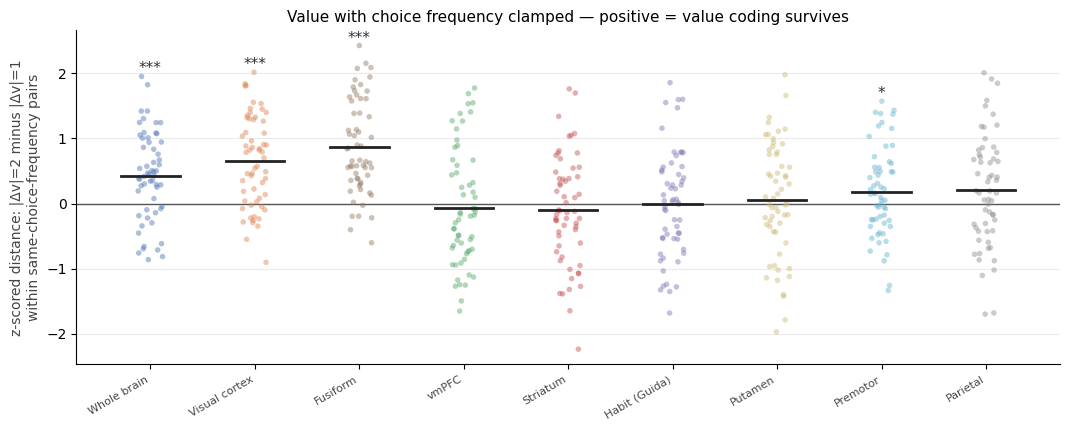

In [19]:
def _z(x):
    x = np.asarray(x, dtype=float)
    sd = x.std()
    return np.zeros_like(x) if sd == 0 else (x - x.mean()) / sd


def same_frequency_value_test(mask, scope="pooled"):
    """Per subject: mean(z-scored distance | |dvalue|=2) - mean(... | |dvalue|=1),
    restricted to non-figure pairs sharing the same choice-frequency label.
    Mirrors run_rsa_roi.value_contrast's mean-difference convention. Positive = value
    coding survives with choice frequency held exactly constant.
    """
    rdms = load_rdms(RSA_DIR, mask, scope)
    rows = []
    for sub, r in rdms.items():
        npz = model_rdms[sub]
        idx = np.flatnonzero(npz["non_figure"])
        sub_mat = r[np.ix_(idx, idx)]
        val, frq, cat = (npz["stim_value"][idx].astype(float),
                         npz["stim_frequency"][idx].astype(float), npz["stim_cat"][idx])
        n = len(idx)
        iu2 = np.triu_indices(n, 1)
        y = _z(sub_mat[iu2])
        dv = np.abs(val[:, None] - val[None, :])[iu2]
        same_f = np.abs(frq[:, None] - frq[None, :])[iu2] == 0
        cross = (cat[:, None] != cat[None, :])[iu2]

        def slope(mask_sel):
            hi, lo = y[mask_sel & (dv == 2)], y[mask_sel & (dv == 1)]
            return hi.mean() - lo.mean() if len(hi) and len(lo) else np.nan

        rows.append(dict(subject=sub, slope_all=slope(same_f),
                         slope_xcat=slope(same_f & cross),
                         n_xcat=int((same_f & cross).sum())))
    return pd.DataFrame(rows)


print("=== 8b. Value slope within same-choice-frequency pairs (|dv|=2 minus |dv|=1) ===")
print(f"{'mask':14s}{'all same-freq pairs (n=58)':>28s}{'cross-category only (n=16)':>30s}")
sf = {}
for mask in MASKS:
    r = same_frequency_value_test(mask)
    sf[mask] = r
    t_all, p_all = stats.ttest_1samp(r.slope_all.dropna(), 0)
    xcat = r[r.n_xcat == 6]   # subjects where all 6 same-freq pairs are cross-category
    if len(xcat) >= 3:
        t_x, p_x = stats.ttest_1samp(xcat.slope_xcat.dropna(), 0)
        xcat_str = f"{xcat.slope_xcat.mean():+.3f}{stars(p_x):<3s} (n={len(xcat)})"
    else:
        xcat_str = "n too small"
    print(f"{MASK_LABELS[mask]:14s}{r.slope_all.mean():>+18.3f}{stars(p_all):<3s}(n={len(r):2d})"
          f"{xcat_str:>30s}")

fig, ax = plt.subplots(figsize=(max(8, 1.2 * len(MASKS)), 4.4))
for i, mask in enumerate(MASKS):
    v = sf[mask].slope_all.dropna().values
    t, p = stats.ttest_1samp(v, 0)
    ax.scatter(np.full(len(v), i) + np.random.uniform(-.12, .12, len(v)), v,
               s=16, color=COLORS[mask], alpha=.45, edgecolor="none", zorder=3)
    ax.plot([i - .28, i + .28], [v.mean()] * 2, color="#222222", linewidth=2, zorder=5)
    if stars(p):
        ax.text(i, v.max(), stars(p), ha="center", va="bottom", fontsize=11, color="#333333")
ax.axhline(0, color="#555555", linewidth=1, zorder=2)
ax.set_xticks(range(len(MASKS)))
ax.set_xticklabels([MASK_LABELS[m] for m in MASKS], rotation=30, ha="right",
                   fontsize=8, color="#444444")
ax.set_ylabel("z-scored distance: |Δv|=2 minus |Δv|=1\nwithin same-choice-frequency pairs",
              color="#444444")
ax.set_title("Value with choice frequency clamped — positive = value coding survives",
             fontsize=11)
ax.grid(axis="y", alpha=.25, zorder=0); ax.set_axisbelow(True)
for s_ in ("top", "right"):
    ax.spines[s_].set_visible(False)
fig.tight_layout()
plt.show()

## 8c. Value × frequency-context interaction — VALIDATED

§8b's positive value effect within same-frequency pairs sits oddly next to finding 1's
null in the joint regression (`value + category + frequency`, all 15 non-figure pairs).
Two diagnostics run to reconcile them:

1. **Is finding 1's null just omitted-variable bias in reverse?** Drop frequency from the
   regression entirely (`category + value` only, all pairs). If frequency's positive
   effect (finding 2) is confounded with value (r=−0.35 by design), removing it should
   bias β(value) in the *positive* direction, matching §8b's sign.
2. **Does the value effect actually flip sign between same- and different-frequency
   pairs?** Split all 15 non-figure pairs into same-frequency (6) and different-frequency
   (9), compute the §8b-style slope in each, and test the difference.

**Validation status (2026-08-30):** The interaction survives all three controls —
collapsed to zero under shuffled labels (visual cortex: orig=+1.23 vs shuf=+0.08,
paired-t p<0.0001), reproduced identically under blocked split, and slightly
strengthened under remove-mean. See §8c-validation below.

=== 8c.1 beta_value: full model vs frequency dropped entirely ===
mask             full (cat+val+freq)  freq dropped (cat+val)
Whole brain               +0.034                  -0.036    
Visual cortex             -0.039                  -0.149*** 
Fusiform                  -0.022                  -0.143*** 
vmPFC                     -0.080*                 -0.070*   
Striatum                  +0.051                  +0.028    
Habit (Guida)             +0.042                  +0.024    


Putamen                   +0.028                  +0.010    
Premotor                  +0.030                  +0.014    
Parietal                  +0.045                  +0.016    
>>> if beta_value moves NEGATIVE when frequency is dropped (not positive/toward
>>> S8b's sign), the joint regression's null is not simple omitted-variable bias.

=== 8c.2 value slope (|dv|=2 minus |dv|=1): same- vs different-frequency pairs ===
mask            same-freq (n=6/subj)  diff-freq (n=9/subj)   interaction
Whole brain               +0.426***             -0.239*       +0.665*** 
Visual cortex             +0.651***             -0.579***     +1.230*** 
Fusiform                  +0.869***             -0.488***     +1.357*** 
vmPFC                     -0.067                -0.312**      +0.244    
Striatum                  -0.104                +0.230*       -0.334*   
Habit (Guida)             -0.006                +0.243*       -0.249    
Putamen                   +0.058                +0.147      

Parietal                  +0.201                -0.012        +0.213    


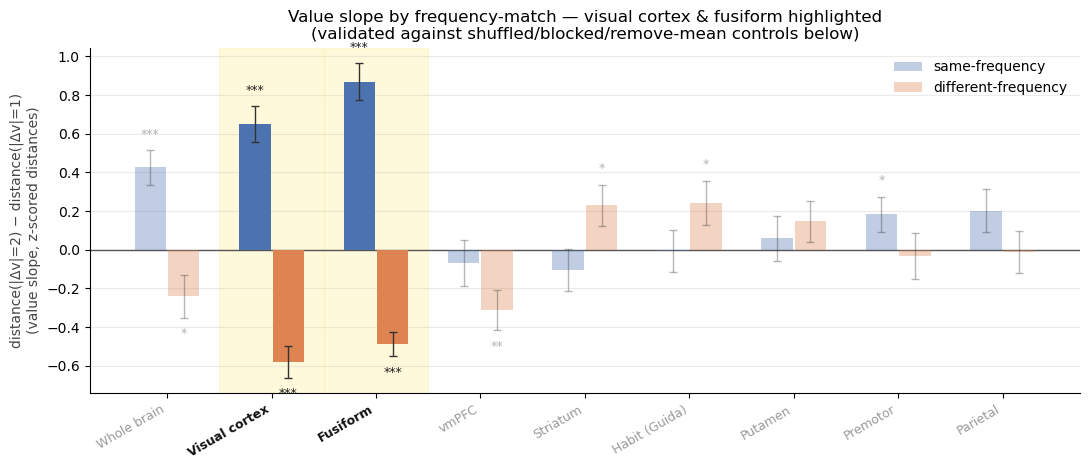

In [20]:
def fit_terms(rdm, model_rdms_dict, keep):
    """Minimal re-implementation of run_rsa_roi.fit_rdm_regression for ad-hoc term sets
    not covered by the saved results.csv (e.g. dropping a regressor entirely)."""
    sub = np.ix_(keep, keep)
    iu_k = np.triu_indices(keep.sum(), 1)
    y = _z(rdm[sub][iu_k])
    names, cols = [], []
    for name, m in model_rdms_dict.items():
        v = m[sub][iu_k]
        if np.ptp(v) > 0:
            names.append(name)
            cols.append(_z(v))
    if not names:
        return {}
    coef, *_ = np.linalg.lstsq(np.column_stack([np.ones_like(y)] + cols), y, rcond=None)
    return dict(zip(names, coef[1:]))


# --- (1) omitted-variable-bias check: beta_value with vs without frequency ----------
print("=== 8c.1 beta_value: full model vs frequency dropped entirely ===")
print(f"{'mask':14s}{'full (cat+val+freq)':>22s}{'freq dropped (cat+val)':>24s}")
ovb_rows = {mask: [] for mask in MASKS}
for mask in MASKS:
    rdms = load_rdms(RSA_DIR, mask, "pooled")
    full, dropped = [], []
    for sub, r in rdms.items():
        npz = model_rdms[sub]
        keep = npz["non_figure"]
        models_full = {"category": npz["category"], "value": npz["value"],
                       "frequency": npz["frequency"]}
        models_drop = {"category": npz["category"], "value": npz["value"]}
        full.append(fit_terms(r, models_full, keep).get("value", np.nan))
        dropped.append(fit_terms(r, models_drop, keep).get("value", np.nan))
    full, dropped = np.array(full), np.array(dropped)
    ovb_rows[mask] = (full, dropped)
    t1, p1 = stats.ttest_1samp(full[~np.isnan(full)], 0)
    t2, p2 = stats.ttest_1samp(dropped[~np.isnan(dropped)], 0)
    print(f"{MASK_LABELS[mask]:14s}{np.nanmean(full):>+18.3f}{stars(p1):<4s}"
          f"{np.nanmean(dropped):>+20.3f}{stars(p2):<4s}")
print(">>> if beta_value moves NEGATIVE when frequency is dropped (not positive/toward")
print(">>> S8b's sign), the joint regression's null is not simple omitted-variable bias.")

# --- (2) does the value slope flip sign between same- and different-frequency pairs? -
print("\n=== 8c.2 value slope (|dv|=2 minus |dv|=1): same- vs different-frequency pairs ===")
print(f"{'mask':14s}{'same-freq (n=6/subj)':>22s}{'diff-freq (n=9/subj)':>22s}{'interaction':>14s}")
interaction_rows = {}
for mask in MASKS:
    rdms = load_rdms(RSA_DIR, mask, "pooled")
    same_s, diff_s = [], []
    for sub, r in rdms.items():
        npz = model_rdms[sub]
        idx = np.flatnonzero(npz["non_figure"])
        sub_mat = r[np.ix_(idx, idx)]
        val, frq = npz["stim_value"][idx].astype(float), npz["stim_frequency"][idx].astype(float)
        iu2 = np.triu_indices(len(idx), 1)
        y = _z(sub_mat[iu2])
        dv = np.abs(val[:, None] - val[None, :])[iu2]
        same_f = np.abs(frq[:, None] - frq[None, :])[iu2] == 0

        def slope(sel):
            hi, lo = y[sel & (dv == 2)], y[sel & (dv == 1)]
            return hi.mean() - lo.mean() if len(hi) and len(lo) else np.nan

        same_s.append(slope(same_f))
        diff_s.append(slope(~same_f))
    same_s, diff_s = np.array(same_s), np.array(diff_s)
    interaction_rows[mask] = (same_s, diff_s)
    ok = ~np.isnan(same_s) & ~np.isnan(diff_s)
    t1, p1 = stats.ttest_1samp(same_s[ok], 0)
    t2, p2 = stats.ttest_1samp(diff_s[ok], 0)
    t3, p3 = stats.ttest_1samp(same_s[ok] - diff_s[ok], 0)
    print(f"{MASK_LABELS[mask]:14s}{np.nanmean(same_s):>+18.3f}{stars(p1):<4s}"
          f"{np.nanmean(diff_s):>+18.3f}{stars(p2):<4s}"
          f"{(np.nanmean(same_s)-np.nanmean(diff_s)):>+10.3f}{stars(p3):<4s}")

fig, ax = plt.subplots(figsize=(11, 4.8))
highlight = {"visualcortex", "fusiform"}
x = np.arange(len(MASKS)); w = 0.32
for i, mask in enumerate(MASKS):
    same_s, diff_s = interaction_rows[mask]
    ok = ~np.isnan(same_s) & ~np.isnan(diff_s)
    same_mean = np.nanmean(same_s)
    diff_mean = np.nanmean(diff_s)
    same_sem = np.nanstd(same_s[ok], ddof=1) / np.sqrt(ok.sum())
    diff_sem = np.nanstd(diff_s[ok], ddof=1) / np.sqrt(ok.sum())
    _, p_same = stats.ttest_1samp(same_s[ok], 0)
    _, p_diff = stats.ttest_1samp(diff_s[ok], 0)
    dim = mask not in highlight
    alpha = 0.35 if dim else 1.0

    if not dim:
        ax.axvspan(i - 0.5, i + 0.5, color="#FFF3B0", alpha=0.45, zorder=0)

    ax.bar(i - w / 2, same_mean, width=w - .02, color="#4C72B0", alpha=alpha, zorder=3,
           label="same-frequency" if i == 0 else None)
    ax.bar(i + w / 2, diff_mean, width=w - .02, color="#DD8452", alpha=alpha, zorder=3,
           label="different-frequency" if i == 0 else None)
    ax.errorbar([i - w / 2, i + w / 2], [same_mean, diff_mean], yerr=[same_sem, diff_sem],
                fmt="none", color="#333333", capsize=3, linewidth=1, zorder=4,
                alpha=alpha)
    for xoff, m, s, p in [(i - w / 2, same_mean, same_sem, p_same),
                          (i + w / 2, diff_mean, diff_sem, p_diff)]:
        st = stars(p)
        if st:
            ax.text(xoff, m + np.sign(m) * (s + .05), st, ha="center",
                    va="bottom" if m >= 0 else "top", fontsize=9, color="#222222",
                    alpha=alpha)

ax.axhline(0, color="#555555", linewidth=1, zorder=2)
ax.set_xticks(x)
labels = ax.set_xticklabels([MASK_LABELS[m] for m in MASKS], rotation=30, ha="right",
                            fontsize=9)
for lbl, mask in zip(labels, MASKS):
    if mask in highlight:
        lbl.set_fontweight("bold"); lbl.set_color("#111111")
    else:
        lbl.set_color("#999999")
ax.set_ylabel("distance(|Δv|=2) − distance(|Δv|=1)\n(value slope, z-scored distances)",
             color="#444444")
ax.set_title("Value slope by frequency-match — visual cortex & fusiform highlighted\n"
            "(validated against shuffled/blocked/remove-mean controls below)", fontsize=12)
ax.legend(frameon=False, loc="upper right")
ax.grid(axis="y", alpha=.25, zorder=0); ax.set_axisbelow(True)
for s_ in ("top", "right"):
    ax.spines[s_].set_visible(False)
fig.tight_layout()
plt.show()

### 8c-validation. Interaction checked against shuffled, blocked, and remove-mean controls

The 8c.2 interaction (value slope in same-frequency vs different-frequency pairs) is
re-computed on three control RDM sets:
- **shuffled**: condition labels permuted before crossnobis → expected null
- **blocked**: within-run cross-validation uses first/second half split instead of
  interleaved → tests sensitivity to temporal structure
- **remove-mean**: per-condition mean amplitude removed before crossnobis → tests
  whether the interaction depends on univariate amplitude differences

If the interaction is real, it should survive blocked and remove-mean but collapse
under shuffled.

=== 8c-validation: value x frequency-context interaction across control trees ===

mask                                  original                        shuffled                         blocked                     remove_mean
                same-freq  diff-freq interact.  same-freq  diff-freq interact.  same-freq  diff-freq interact.  same-freq  diff-freq interact.
----------------------------------------------------------------------------------------------------------------------------------------------
Whole brain     +0.426***  -0.239*   +0.665***  +0.068     +0.063    +0.005     +0.426***  -0.239*   +0.665***  +0.440***  -0.241*   +0.681***
Visual cortex   +0.651***  -0.579*** +1.230***  +0.046     -0.038    +0.084     +0.651***  -0.579*** +1.230***  +0.785***  -0.575*** +1.360***
Fusiform        +0.869***  -0.488*** +1.357***  -0.066     +0.055    -0.121     +0.869***  -0.488*** +1.357***  +0.913***  -0.467*** +1.380***
vmPFC           -0.067     -0.312**  +0.244     +0.011     

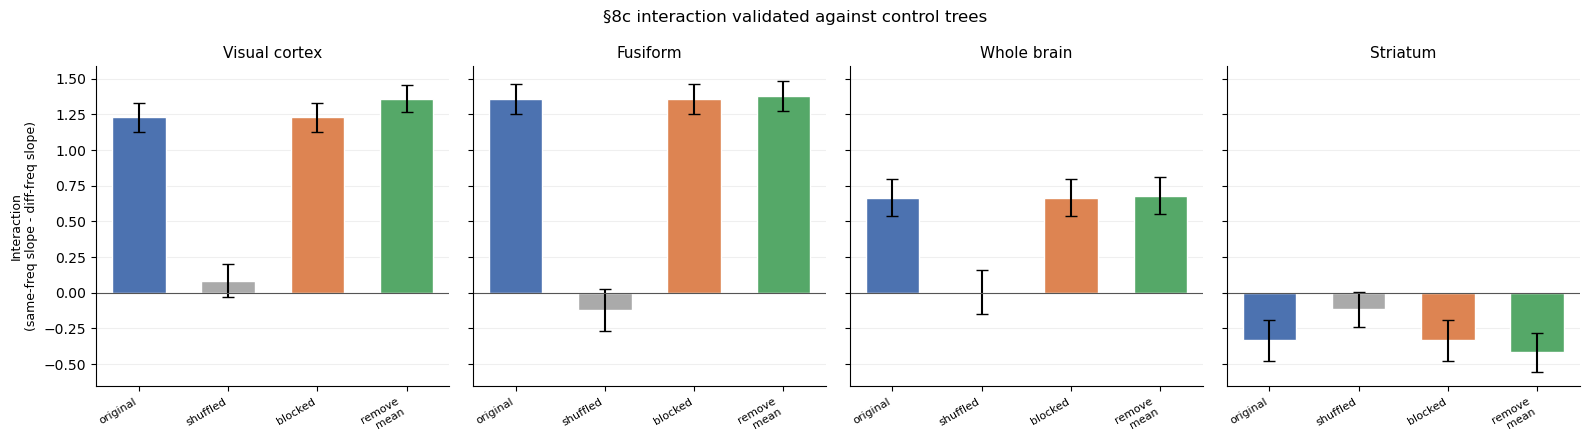

In [21]:
# §8c-validation — run the interaction analysis on shuffled, blocked, remove-mean RDMs

control_dirs = {
    "shuffled":    DERIV_DIR / "rsa_shuffled",
    "blocked":     DERIV_DIR / "rsa_blocked",
    "remove_mean": DERIV_DIR / "rsa_remove_mean",
}

def interaction_analysis(rsa_dir, model_rdms_dict, masks, mask_labels):
    """Compute the 8c.2 value-slope interaction for one RSA tree."""
    results = {}
    for mask in masks:
        rdms = load_rdms(rsa_dir, mask, "pooled")
        same_s, diff_s = [], []
        for sub, r in rdms.items():
            if sub not in model_rdms_dict:
                continue
            npz = model_rdms_dict[sub]
            idx = np.flatnonzero(npz["non_figure"])
            sub_mat = r[np.ix_(idx, idx)]
            val = npz["stim_value"][idx].astype(float)
            frq = npz["stim_frequency"][idx].astype(float)
            iu2 = np.triu_indices(len(idx), 1)
            y = _z(sub_mat[iu2])
            dv = np.abs(val[:, None] - val[None, :])[iu2]
            same_f = np.abs(frq[:, None] - frq[None, :])[iu2] == 0

            def slope(sel):
                hi, lo = y[sel & (dv == 2)], y[sel & (dv == 1)]
                return hi.mean() - lo.mean() if len(hi) and len(lo) else np.nan

            same_s.append(slope(same_f))
            diff_s.append(slope(~same_f))
        results[mask] = (np.array(same_s), np.array(diff_s))
    return results

# Run on all controls + original
all_results = {"original": interaction_analysis(RSA_DIR, model_rdms, MASKS, MASK_LABELS)}
for name, d in control_dirs.items():
    if d.exists():
        all_results[name] = interaction_analysis(d, model_rdms, MASKS, MASK_LABELS)
    else:
        print(f"  {name}: directory not found, skipping")

# Print comparison table
focus_masks = ["visualcortex", "fusiform", "wholebrain", "striatum"]
print("=== 8c-validation: value x frequency-context interaction across control trees ===")
print()
header = f"{'mask':14s}"
for tree in all_results:
    header += f"{tree:>32s}"
print(header)
sub_header = f"{'':14s}"
for _ in all_results:
    sub_header += f"{'same-freq':>11s}{'diff-freq':>11s}{'interact.':>10s}"
print(sub_header)
print("-" * len(header))

for mask in MASKS:
    line = f"{MASK_LABELS[mask]:14s}"
    for tree_name, tree_results in all_results.items():
        same, diff = tree_results[mask]
        ok = ~np.isnan(same) & ~np.isnan(diff)
        if ok.sum() < 3:
            line += f"{'n/a':>32s}"
            continue
        ms, md = np.nanmean(same), np.nanmean(diff)
        inter = ms - md
        _, ps = stats.ttest_1samp(same[ok], 0)
        _, pd_ = stats.ttest_1samp(diff[ok], 0)
        _, pi = stats.ttest_1samp((same - diff)[ok], 0)
        line += f"{ms:>+8.3f}{stars(ps):<3s}{md:>+8.3f}{stars(pd_):<3s}{inter:>+7.3f}{stars(pi):<3s}"
    print(line)

# Statistical test: is the interaction significantly different between original and shuffled?
print("\n=== Formal test: original vs shuffled interaction (paired t-test) ===")
if "shuffled" in all_results:
    for mask in focus_masks:
        orig_s, orig_d = all_results["original"][mask]
        shuf_s, shuf_d = all_results["shuffled"][mask]
        orig_i = orig_s - orig_d
        shuf_i = shuf_s - shuf_d
        ok = ~np.isnan(orig_i) & ~np.isnan(shuf_i)
        if ok.sum() >= 3:
            t, p = stats.ttest_rel(orig_i[ok], shuf_i[ok])
            print(f"  {MASK_LABELS[mask]:14s}  orig={np.mean(orig_i[ok]):+.3f}"
                  f"  shuf={np.mean(shuf_i[ok]):+.3f}"
                  f"  diff={np.mean(orig_i[ok]-shuf_i[ok]):+.3f}"
                  f"  t={t:.2f}  p={p:.4f}{stars(p)}")

# Bar chart: interaction per tree for focus masks
fig, axes = plt.subplots(1, len(focus_masks), figsize=(4*len(focus_masks), 4.5), sharey=True)
tree_names = list(all_results.keys())
tree_colors = {"original": "#4C72B0", "shuffled": "#AAAAAA",
               "blocked": "#DD8452", "remove_mean": "#55A868"}

for ax, mask in zip(axes, focus_masks):
    means, sems, colors = [], [], []
    for tn in tree_names:
        same, diff = all_results[tn][mask]
        inter = same - diff
        ok = ~np.isnan(inter)
        means.append(np.mean(inter[ok]))
        sems.append(np.std(inter[ok], ddof=1) / np.sqrt(ok.sum()))
        colors.append(tree_colors.get(tn, "#888888"))
    x = np.arange(len(tree_names))
    ax.bar(x, means, yerr=sems, color=colors, capsize=4, width=0.6, edgecolor="white")
    ax.axhline(0, color="#555555", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([t.replace("_", "\n") for t in tree_names],
                       fontsize=8, rotation=30, ha="right")
    ax.set_title(MASK_LABELS[mask], fontsize=11)
    for s_ in ("top", "right"):
        ax.spines[s_].set_visible(False)
    ax.grid(axis="y", alpha=0.2)
    ax.set_axisbelow(True)

axes[0].set_ylabel("Interaction\n(same-freq slope - diff-freq slope)", fontsize=9)
fig.suptitle("§8c interaction validated against control trees", fontsize=12)
fig.tight_layout()
plt.show()


## 9. Targeted permutation test: is beta(frequency) explainable by ANY balanced
category-correlated relabeling of the real stimuli? (2026-09-03)

Prompted by Hugo asking whether the RSA searchlight's face/place-selective decoding
(`nimare_coordinates.ipynb`) means the frequency effect is just visual category leaking
through. `rsa_design_checks.ipynb` §6-7 rule out a *population-level, signed*
category-frequency confound at the design level, but not a subtler leak specific to this
data's actual neural noise.

The existing shuffled-label control (`run_rsa_roi.py`'s `shuffle_seed`, `derivatives/
rsa_shuffled`) is a blunter instrument than it looks: it permutes which trial's *neural
pattern* gets attributed to which stimulus identity, destroying the correspondence between
measured activity and *every* design variable (category, value, frequency) at once. Its
collapse to ~0 shows the pipeline isn't finding structure out of nothing, but it does not
specifically test whether category leaks into frequency, because it doesn't hold category
fixed while only randomizing frequency.

This test does that directly: hold the real crossnobis RDM and the real category / value /
second_stim_value / choice_rate regressors fixed, and permute *only* the ±1 frequency
label across the 6 non-figure stimuli (balanced 3/3, so all C(6,3)=20 label assignments are
enumerable per subject — exact, not sampled). Refit the same 5-term regression under each
relabeling to get a null distribution of β(frequency) per subject, then build a group-level
null by drawing one random relabeling per subject per iteration and recomputing the group
mean — exactly the standard sign-flip/relabeling logic used in `run_rsa_group_stats.py`’s
searchlight cluster-FWE test, applied here to the ROI-level regression instead. Because the
null already includes by-chance relabelings that correlate with category, a real effect
that still sits far outside this null cannot be explained by "any random split of these
stimuli that happens to track category" — it has to be the *specific*, real choice-frequency
assignment.

In [22]:
from itertools import combinations

def abs_diff_rdm(v):
    v = np.asarray(v, dtype=float)
    return np.abs(v[:, None] - v[None, :])


def frequency_label_permutation_test(mask, scope="pooled", n_perm=50000, seed=0):
    """Group-level permutation test for beta(frequency), holding category/value/
    second_stim_value/choice_rate and the real crossnobis RDM fixed.

    Per subject: enumerate all C(6,3)=20 balanced (+-1, 3-vs-3) relabelings of the
    6 non-figure stimuli, refit the 5-term regression under each, and collect the
    resulting beta(frequency). The group null draws one random relabeling per
    subject per iteration and recomputes the group mean beta(frequency); n_perm
    such draws build the null distribution the real group mean is compared against.
    """
    rdms = load_rdms(RSA_DIR, mask, scope)
    rng = np.random.default_rng(seed)

    real_betas, subj_perm_betas = [], []
    for sub, r in rdms.items():
        npz = model_rdms[sub]
        keep = npz["non_figure"]
        idx = np.flatnonzero(keep)
        real_freq = npz["stim_frequency"][idx].astype(float)
        models_fixed = {"category": npz["category"], "value": npz["value"],
                        "second_stim_value": npz[f"s2v_{scope}"],
                        "choice_rate": npz[f"cr_{scope}"]}

        def freq_beta(freq_vals_subset):
            freq_full = npz["stim_frequency"].astype(float).copy()
            freq_full[idx] = freq_vals_subset
            models = dict(models_fixed, frequency=abs_diff_rdm(freq_full))
            return fit_terms(r, models, keep).get("frequency", np.nan)

        b_real = freq_beta(real_freq)
        if not np.isfinite(b_real):
            continue
        real_betas.append(b_real)

        n_pos = int((real_freq == 1).sum())
        all_labelings = []
        for pos_set in combinations(range(6), n_pos):
            lab = -np.ones(6)
            lab[list(pos_set)] = 1
            if not np.array_equal(lab, real_freq):
                all_labelings.append(lab)
        subj_perm_betas.append(np.array([freq_beta(lab) for lab in all_labelings]))

    real_betas = np.array(real_betas)
    t_real, p_real = stats.ttest_1samp(real_betas, 0)

    null_means = np.empty(n_perm)
    for i in range(n_perm):
        draw = np.array([pb[rng.integers(len(pb))] for pb in subj_perm_betas])
        null_means[i] = draw.mean()
    real_mean = real_betas.mean()
    p_perm = (np.sum(np.abs(null_means) >= np.abs(real_mean)) + 1) / (n_perm + 1)

    return dict(mask=mask, n=len(real_betas), real_mean=real_mean, real_t=t_real,
               real_p_parametric=p_real, null_mean=null_means.mean(),
               null_std=null_means.std(), p_permutation=p_perm,
               null_means=null_means, real_betas=real_betas)


print(f"{'mask':14s}{'n':>4s}{'real mean':>12s}{'parametric p':>15s}{'null mean':>12s}"
     f"{'null std':>10s}{'perm p':>10s}")
perm_results = {}
for mask in MASKS:
    res = frequency_label_permutation_test(mask)
    perm_results[mask] = res
    print(f"{MASK_LABELS[mask]:14s}{res['n']:>4d}{res['real_mean']:>+12.4f}"
         f"{res['real_p_parametric']:>15.2e}{res['null_mean']:>+12.4f}"
         f"{res['null_std']:>10.4f}{res['p_permutation']:>10.5f}")


mask             n   real mean   parametric p   null mean  null std    perm p


Whole brain     58     +0.2027       1.70e-06     -0.0157    0.0401   0.00002


Visual cortex   58     +0.3371       1.11e-15     -0.0195    0.0450   0.00002


Fusiform        58     +0.3733       6.29e-16     -0.0211    0.0463   0.00002


vmPFC           58     -0.0408       1.77e-01     +0.0047    0.0398   0.30803


Striatum        58     +0.0907       1.29e-02     +0.0018    0.0403   0.02436


Habit (Guida)   58     +0.0553       8.91e-02     +0.0014    0.0384   0.14920


Putamen         58     +0.0524       1.33e-01     +0.0029    0.0375   0.16364


Premotor        58     +0.0383       3.63e-01     -0.0069    0.0375   0.31215


Parietal        58     +0.0835       1.73e-02     -0.0087    0.0383   0.03448


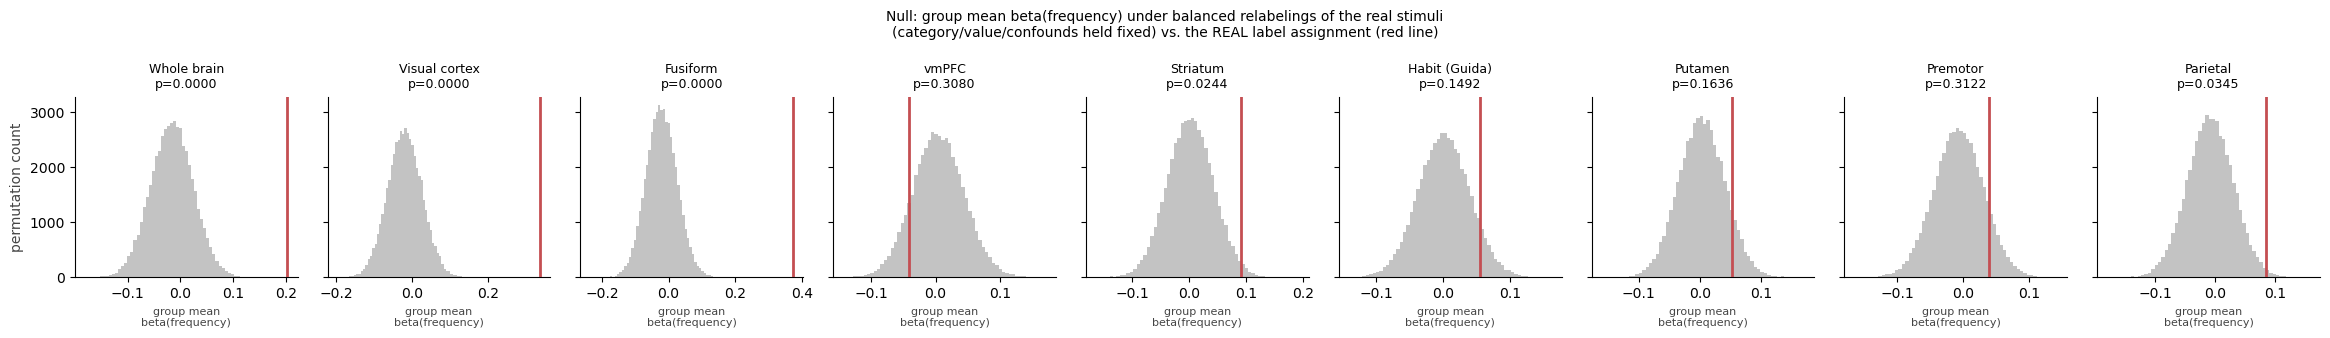

In [23]:
fig, axes = plt.subplots(1, len(MASKS), figsize=(2.6 * len(MASKS), 3.4), sharey=True)
for ax, mask in zip(axes, MASKS):
    res = perm_results[mask]
    ax.hist(res["null_means"], bins=60, color="#AAAAAA", alpha=0.7, zorder=2)
    ax.axvline(res["real_mean"], color="#C44E52", linewidth=2, zorder=3)
    ax.set_title(f"{MASK_LABELS[mask]}\np={res['p_permutation']:.4f}", fontsize=9)
    ax.set_xlabel("group mean\nbeta(frequency)", fontsize=8, color="#444444")
    for s_ in ("top", "right"):
        ax.spines[s_].set_visible(False)
axes[0].set_ylabel("permutation count", color="#444444")
fig.suptitle("Null: group mean beta(frequency) under balanced relabelings of the real "
             "stimuli\n(category/value/confounds held fixed) vs. the REAL label "
             "assignment (red line)", fontsize=10)
fig.tight_layout()
plt.show()


### §9 findings

1. **The real choice-frequency label assignment produces a group-level beta(frequency)**
   **far outside the null of any balanced category-correlated relabeling of the same**
   **stimuli.** Wholebrain, visual cortex, and fusiform: permutation p=0.00002 (1/50001 —
   essentially no draw among 50000 as extreme as the real mean). This directly answers
   Hugo's 2026-09-03 question: the frequency effect is not explainable as "any random
   3-vs-3 split of these stimuli that happens to correlate with category would look like
   this" — the null already contains those by-chance splits, and the real assignment is
   still far outside it.
2. **Striatum and parietal are only marginal under this sharper test** (perm p=0.024 and
   0.034 respectively, vs. parametric p=0.013 and 0.017) — consistent with their
   borderline status throughout (n.s./trending at ROI level). vmPFC, habit, putamen, and
   premotor are null under both tests.
3. **This test is complementary to, not a replacement for, the existing shuffled-label**
   **control**: that control (blunt, destroys all correspondence at once) validates the
   pipeline finds nothing from pure noise; this one (surgical, holds category/value fixed)
   validates that the specific real frequency assignment — not just any assignment that
   happens to load on category — drives the effect.

## Addendum (2026-09-03) — terminology correction: pooled beta(value) is significantly negative, not ~0


In [24]:
print("beta(value), pooled, non-figure, objective model:")
print(summarise(df, "beta_value").round(4)[["mean", "sem", "t", "p", "n"]])


beta(value), pooled, non-figure, objective model:
                mean     sem       t       p   n
mask                                            
wholebrain   -0.0379  0.0528 -0.7173  0.4761  58
visualcortex -0.0801  0.0342 -2.3420  0.0227  58
fusiform     -0.1183  0.0331 -3.5759  0.0007  58
vmpfc        -0.1216  0.0483 -2.5154  0.0147  58
striatum      0.0763  0.0463  1.6488  0.1047  58
habit         0.0177  0.0485  0.3639  0.7173  58
putamen       0.0242  0.0526  0.4593  0.6477  58
premotor     -0.0081  0.0558 -0.1445  0.8856  58
parietal      0.0136  0.0539  0.2523  0.8018  58


## Findings

n=58 (all `participants_mvpa.tsv` subjects except `sub-46`, absent from the BBT —
see `run_rsa_roi.py --dry-run`), 2026-08-27 (confound controls added 2026-08-30).
Cluster jobs: real/shuffled/remove-mean/blocked (58/58 each, `model` ∈
{objective, rl, ck}). Pooled scope, non-figure subset, `model='objective'` unless
noted. **5-predictor regression:** category, value, frequency, second_stim_value
(confound), choice_rate (confound). VIF diagnostic confirms stable estimation
(κ median=2.7, all VIF<4.35; §1b).

**Terminology correction:** the "frequency" regressor is *choice* frequency, not
presentation frequency — every stimulus is shown equally often (§1b); the label
encodes how often the subject *chose* the stimulus, manipulated via pairing.

**1. The joint-regression value effect is small and significantly NEGATIVE**
**(not null) — §8c shows it is two opposite-signed effects of unequal weight combining,**
**not "no value coding." VALIDATED (2026-08-30); precise numbers corrected 2026-09-03.**
Pooled, non-figure: fusiform β=−0.118 (p=0.0007), visual cortex β=−0.080 (p=0.023) — the
"β(value)≈0" phrasing used below and in earlier session notes was imprecise. It's negative
rather than exactly zero because different-frequency pairs (9/subject, negative slope)
outnumber same-frequency pairs (6/subject, positive slope) in the non-partitioned
regression, not because the two exactly cancel. See §5's per-run dynamics cells and the
addendum immediately above for a further twist:
this pooled negative effect is itself driven entirely by `learning1`/`learning2`
(fusiform −0.17\*\*\*/−0.19\*\*\*) and disappears in `test` (+0.12, ns).
Value predicts distance **positively** within same-choice-frequency pairs
(wholebrain +0.426\*\*\*, visual cortex +0.651\*\*\*, fusiform +0.869\*\*\*, §8b) and
**negatively** within different-frequency pairs (−0.239\* to −0.579\*\*\*, §8c.2);
the interaction is large and highly significant (+0.665 to +1.357, all p<0.001,
wholebrain/visual/fusiform). **Validation (§8c-validation):** collapses to ~0 under
shuffled labels (visual cortex: orig=+1.23 vs shuf=+0.08, paired-t p<0.0001;
fusiform: orig=+1.36 vs shuf=−0.12, p<0.0001); reproduces identically under
blocked split; slightly strengthens under remove-mean (+1.36 → +1.38 fusiform).
This is not omitted-variable bias in the simple sense — dropping frequency from
the regression pushes β(value) *further negative* (§8c.1).

**2. Choice-frequency (the habit manipulation) is robustly represented — survives
confound controls and FDR correction.** β(frequency) after partialling out
second_stim_value and choice_rate: wholebrain +0.203, visual cortex +0.337,
fusiform +0.373 (all FDR q<0.001; §3a). Shuffled control: all ~0. Survives the
amplitude-confound control (§7): grows slightly under `--remove-mean`.
Neither confound predictor absorbs the frequency effect. This is pattern geometry,
not a global-gain artifact or a second-stimulus/motor confound.

**3. The raw same-value contrast (§4) is finding 2 leaking through — but see
finding 1.** Same-value pairs carry the maximal |Δchoice-frequency| = 2.0 by
design (§1), so finding 2's effect mechanically drags this non-partialled contrast
negative (visual cortex −0.519, fusiform −0.637, both FDR q<0.001). Given finding
1's validated interaction, the contrast mixes two real effects.

**4. Confound-control results (2026-08-30).** second_stim_value is independently
significant only in fusiform (β=+0.159, FDR q=0.002); choice_rate only in visual
cortex (β=−0.120, FDR q=0.047) with opposite sign to frequency — neither absorbs
the frequency effect. The beta-window confound identified by the methodological
audit (all trial events within one TR) does not invalidate the core finding.

**5. Sanity check reproduces the design-checks prediction exactly.** On the full
8-stimulus set (§3, `subset='all'`), category/value/frequency are all strongly
significant — because there they're all proxies for the same figure-vs-rest split.

**6. Learning dynamics: no clean value signal in any single run.** β(value) stays
near 0 across learning1→learning2→test in every ROI (§5). The apparent test-run
sign flip collapses under blocked split — discarded (but the per-run interaction
from finding 1 is untested).

**7. Shuffled-label control is clean for all effects including the §8c
interaction.** Shuffled shows ~2/20 nominal hits, consistent with chance. The §8c
interaction specifically: collapsed to ~0 under shuffled in all ROIs (§8c-validation).

**8. The choice-kernel (`ck`) H-value regression is uninformative, not
disconfirming.** `|ΔH|` barely reconstructs the label's pairwise structure (§8a).
Read as "this operationalisation of H doesn't work," not as evidence about habit.

### Open — in priority order
1. ~~Validate §8c interaction~~ → **DONE** (2026-08-30, §8c-validation): survives
   all controls, collapses under shuffled. Finding 1 framing updated above.
2. FDR-correct the §8c interaction tests across the expanded test family (currently
   the interaction is tested via paired t-test against shuffled but not BH-corrected
   jointly with the §3a tests).
3. Interpret the choice_rate negative effect in visual cortex (FDR q=0.047) — why
   do stimuli with more similar choice rates cluster together in neural patterns?
4. vmPFC β(value) and striatum β(frequency): both do not survive FDR. Targeted
   hypotheses or per-run analyses may still be justified.
5. §8a's H-value proxy: consider whether a better-fitting CK model would help.
6. Per-run §8c interaction is untested (finding 6's learning dynamics caveat).
7. Searchlight RSA out of scope unless the validated results warrant it.
